**Minnesota actual baseline and 2025–26 league environment**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

player_url = "https://github.com/sportsdataverse/sportsdataverse-data/releases/download/espn_nba_player_boxscores/player_box_2026.parquet"
team_url = "https://github.com/sportsdataverse/sportsdataverse-data/releases/download/espn_nba_team_boxscores/team_box_2026.parquet"

players = pd.read_parquet(player_url)
teams = pd.read_parquet(team_url)

special_games = [
    "401838140",
    "401838141",
    "401838143",
    "401809839"
]

teams["game_id"] = teams["game_id"].astype(str)

teams_rs = teams[
    (teams["season"] == 2026) &
    (teams["season_type"] == 2) &
    (~teams["game_id"].isin(special_games))
].copy()

valid_nba_teams = {
    "ATL", "BOS", "BKN", "CHA", "CHI", "CLE", "DAL", "DEN",
    "DET", "GSW", "HOU", "IND", "LAC", "LAL", "MEM", "MIA",
    "MIL", "MIN", "NOP", "NYK", "OKC", "ORL", "PHI", "PHX",
    "POR", "SAC", "SAS", "TOR", "UTA", "WAS"
}

teams_rs = teams_rs[
    teams_rs["team_abbreviation"].isin(valid_nba_teams)
].copy()

teams_rs["Possessions"] = (
    teams_rs["field_goals_attempted"]
    + 0.44 * teams_rs["free_throws_attempted"]
    - teams_rs["offensive_rebounds"]
    + teams_rs["turnovers"]
)

teams_rs["ORTG"] = (
    teams_rs["team_score"]
    / teams_rs["Possessions"]
    * 100
)

teams_rs["DRTG"] = (
    teams_rs["opponent_team_score"]
    / teams_rs["Possessions"]
    * 100
)

teams_rs["Net_Rating"] = (
    teams_rs["ORTG"]
    - teams_rs["DRTG"]
)

league_team_summary = (
    teams_rs
    .groupby(["team_abbreviation", "team_display_name"])
    .agg(
        GP=("game_id", "nunique"),
        PPG=("team_score", "mean"),
        Opp_PPG=("opponent_team_score", "mean"),
        ORTG=("ORTG", "mean"),
        DRTG=("DRTG", "mean"),
        Net_Rating=("Net_Rating", "mean"),
        Possessions=("Possessions", "mean"),
        ThreePA=("three_point_field_goals_attempted", "mean"),
        TOV=("turnovers", "mean")
    )
    .reset_index()
)

wolves_team = teams_rs[
    teams_rs["team_abbreviation"] == "MIN"
].copy()

wolves_baseline = pd.Series({
    "Games": wolves_team["game_id"].nunique(),
    "PPG": wolves_team["team_score"].mean(),
    "Opp_PPG": wolves_team["opponent_team_score"].mean(),
    "ORTG": wolves_team["ORTG"].mean(),
    "DRTG": wolves_team["DRTG"].mean(),
    "Net_Rating": wolves_team["Net_Rating"].mean(),
    "3PA": wolves_team["three_point_field_goals_attempted"].mean(),
    "FTA": wolves_team["free_throws_attempted"].mean(),
    "TOV": wolves_team["turnovers"].mean(),
    "Possessions": wolves_team["Possessions"].mean()
})

print("Minnesota 2025-26 baseline")
print(wolves_baseline.round(2))

contender_environment = (
    league_team_summary[
        league_team_summary["team_abbreviation"] != "MIN"
    ]
    .sort_values("Net_Rating", ascending=False)
    .reset_index(drop=True)
)

print("\nTop teams by 2025-26 regular-season Net Rating")
print(
    contender_environment[
        ["team_abbreviation", "team_display_name", "Net_Rating", "ORTG", "DRTG", "PPG"]
    ]
    .head(10)
    .round(2)
)

Minnesota 2025-26 baseline
Games           82.00
PPG            118.00
Opp_PPG        114.65
ORTG           114.90
DRTG           111.85
Net_Rating       3.05
3PA             37.18
FTA             25.27
TOV             14.12
Possessions    102.72
dtype: float64

Top teams by 2025-26 regular-season Net Rating
  team_abbreviation      team_display_name  Net_Rating    ORTG    DRTG     PPG
0               OKC  Oklahoma City Thunder       10.86  117.00  106.14  119.02
1               DET        Detroit Pistons        8.08  115.48  107.40  117.77
2               BOS         Boston Celtics        7.99  117.96  109.97  114.85
3               HOU        Houston Rockets        5.31  116.05  110.73  115.23
4               DEN         Denver Nuggets        5.10  120.33  115.23  122.07
5               CHA      Charlotte Hornets        4.92  115.95  111.04  116.01
6               CLE    Cleveland Cavaliers        4.01  117.09  113.08  119.52
7               TOR        Toronto Raptors        2.59  11

**Building the LaMelo impact anchor and realization scenarios**

In [ ]:
# LaMelo offensive impact anchor

lamelo_off_epm = 4.8
lamelo_minutes = 30
full_game_minutes = 48

minute_adjusted_impact = (
    lamelo_off_epm
    * lamelo_minutes
    / full_game_minutes
)

scenarios = pd.DataFrame({
    "Scenario": [
        "Conservative",
        "Base",
        "Aggressive"
    ],
    "Realization": [
        0.50,
        0.75,
        1.00
    ]
})

scenarios["LaMelo_ORTG_Impact"] = (
    minute_adjusted_impact
    * scenarios["Realization"]
)

scenarios["Projected_ORTG"] = (
    wolves_baseline["ORTG"]
    + scenarios["LaMelo_ORTG_Impact"]
)

scenarios["Projected_NET"] = (
    wolves_baseline["Net_Rating"]
    + scenarios["LaMelo_ORTG_Impact"]
)

scenarios.round(2)

,Scenario,Realization,LaMelo_ORTG_Impact,Projected_ORTG,Projected_NET
0,Conservative,0.50,1.50,116.40,4.55
1,Base,0.75,2.25,117.15,5.30
2,Aggressive,1.00,3.00,117.90,6.05


**Comparing the hypothetical Minnesota with the actual 2025–26 contender environment**

In [ ]:
comparison = pd.concat([
    pd.DataFrame({
        "Team": ["Minnesota Actual"],
        "Type": ["Actual"],
        "Net_Rating": [wolves_baseline["Net_Rating"]]
    }),
    pd.DataFrame({
        "Team": "Minnesota + LaMelo " + scenarios["Scenario"],
        "Type": "Hypothetical",
        "Net_Rating": scenarios["Projected_NET"]
    }),
    contender_environment[
        contender_environment["Net_Rating"] >= 5.0
    ][["team_display_name", "Net_Rating"]]
    .rename(columns={
        "team_display_name": "Team"
    })
    .assign(Type="Actual")
    [["Team", "Type", "Net_Rating"]]
], ignore_index=True)

comparison = comparison.sort_values(
    "Net_Rating",
    ascending=False
).reset_index(drop=True)

comparison.round(2)

,Team,Type,Net_Rating
0,Oklahoma City Thunder,Actual,10.86
1,Detroit Pistons,Actual,8.08
2,Boston Celtics,Actual,7.99
3,Minnesota + LaMelo Aggressive,Hypothetical,6.05
4,Houston Rockets,Actual,5.31
5,Minnesota + LaMelo Base,Hypothetical,5.30
6,Denver Nuggets,Actual,5.10
7,Minnesota + LaMelo Conservative,Hypothetical,4.55
8,Minnesota Actual,Actual,3.05


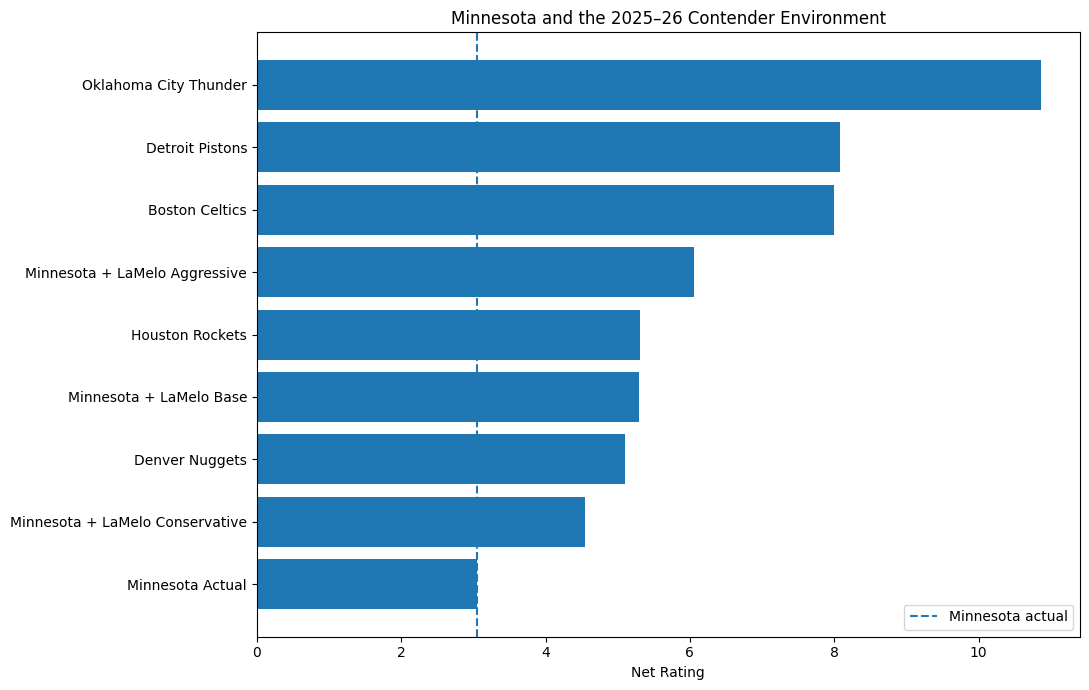

In [ ]:
plt.figure(figsize=(11, 7))

plt.barh(
    comparison["Team"],
    comparison["Net_Rating"]
)

plt.axvline(
    wolves_baseline["Net_Rating"],
    linestyle="--",
    linewidth=1.5,
    label="Minnesota actual"
)

plt.xlabel("Net Rating")
plt.ylabel("")
plt.title("Minnesota and the 2025–26 Contender Environment")
plt.gca().invert_yaxis()
plt.legend()
plt.tight_layout()
plt.show()

**Building the 2026–27 contender roster-change model**

In [ ]:
import pandas as pd
import numpy as np

# =========================================================
# 1. Load 2025-26 SportsDataverse player data
# =========================================================

player_url = (
    "https://github.com/sportsdataverse/"
    "sportsdataverse-data/releases/download/"
    "espn_nba_player_boxscores/player_box_2026.parquet"
)

players = pd.read_parquet(player_url)

players["game_id"] = players["game_id"].astype(str)

special_games = [
    "401838140",
    "401838141",
    "401838143",
    "401809839"
]

players_rs = players[
    (players["season"] == 2026) &
    (players["season_type"] == 2) &
    (~players["game_id"].isin(special_games))
].copy()


# =========================================================
# 2. Build 2025-26 player-season summaries
# =========================================================

player_summary = (
    players_rs
    .groupby(
        [
            "athlete_display_name",
            "team_abbreviation",
            "team_display_name"
        ]
    )
    .agg(
        GP=("game_id", "nunique"),
        MPG=("minutes", "mean"),
        PPG=("points", "mean"),
        APG=("assists", "mean"),
        RPG=("rebounds", "mean"),
        FGA=("field_goals_attempted", "mean"),
        ThreePA=("three_point_field_goals_attempted", "mean"),
        FTA=("free_throws_attempted", "mean"),
        TOV=("turnovers", "mean")
    )
    .reset_index()
)


# =========================================================
# 3. Create a player lookup
# =========================================================

player_lookup = (
    player_summary
    .sort_values(
        ["athlete_display_name", "GP"],
        ascending=[True, False]
    )
    .drop_duplicates(
        subset=["athlete_display_name"]
    )
    .set_index("athlete_display_name")
)


# =========================================================
# 4. Define the 2026-27 contender comparison
# =========================================================

comparison_teams = {
    "Minnesota + LaMelo": "MIN",
    "Miami + Giannis": "MIA",
    "Philadelphia + LeBron/Brown": "PHI",
    "Boston + Paul George": "BOS",
    "San Antonio": "SAS",
    "Oklahoma City": "OKC",
    "Detroit": "DET",
    "New York": "NYK",
    "Denver": "DEN",
    "Indiana": "IND"
}


# =========================================================
# 5. Define major rotation-level roster changes
# =========================================================

roster_changes = {

    "Miami + Giannis": {
        "incoming": [
            "Giannis Antetokounmpo",
            "Bobby Portis",
            "Klay Thompson",
            "Tim Hardaway Jr.",
            "Nick Richards"
        ],
        "outgoing": [
            "Tyler Herro",
            "Norman Powell",
            "Jaime Jaquez Jr.",
            "Kel'el Ware"
        ]
    },

    "Philadelphia + LeBron/Brown": {
        "incoming": [
            "Jaylen Brown",
            "LeBron James",
            "Anfernee Simons",
            "Kentavious Caldwell-Pope",
            "Dean Wade"
        ],
        "outgoing": [
            "Paul George",
            "Kelly Oubre Jr.",
            "Quentin Grimes",
            "Andre Drummond"
        ]
    },

    "Boston + Paul George": {
        "incoming": [
            "Paul George",
            "Mike Conley",
            "Mitchell Robinson"
        ],
        "outgoing": [
            "Jaylen Brown",
            "Nikola Vucevic"
        ]
    },

    "San Antonio": {
        "incoming": [
            "Tobias Harris"
        ],
        "outgoing": []
    },

    "Oklahoma City": {
        "incoming": [],
        "outgoing": [
            "Luguentz Dort",
            "Isaiah Joe",
            "Aaron Wiggins"
        ]
    },

    "Detroit": {
        "incoming": [
            "John Collins",
            "Gary Harris",
            "Isaiah Joe",
            "Taurean Prince"
        ],
        "outgoing": [
            "Tobias Harris",
            "Caris LeVert",
            "Isaiah Stewart",
            "Marcus Sasser"
        ]
    },

    "New York": {
        "incoming": [
            "Andre Drummond"
        ],
        "outgoing": [
            "Mitchell Robinson",
            "Jeremy Sochan"
        ]
    },

    "Denver": {
        "incoming": [
            "DeMar DeRozan",
            "Marvin Bagley III",
            "Lonnie Walker IV"
        ],
        "outgoing": [
            "Tim Hardaway Jr.",
            "Peyton Watson"
        ]
    },

    "Indiana": {
        "incoming": [
            "Larry Nance Jr.",
            "Kelly Oubre Jr."
        ],
        "outgoing": [
            "Kam Jones"
        ]
    }
}


# =========================================================
# 6. Match player names against SportsDataverse
# =========================================================

def normalize_name(name):

    name = str(name).lower().strip()

    replacements = {
        "kel'el ware": "kel'el ware",
        "nikola vucevic": "nikola vucevic",
        "deandre ayton": "deandre ayton"
    }

    return replacements.get(name, name)


player_names = {
    normalize_name(name): name
    for name in player_lookup.index
}


def find_player(player_name):

    target = normalize_name(player_name)

    # Exact match
    if target in player_names:
        return player_names[target]

    # Case-insensitive direct comparison
    for actual_name in player_lookup.index:

        if normalize_name(actual_name) == target:
            return actual_name

    return None


# =========================================================
# 7. Build player-level transaction table
# =========================================================

transaction_rows = []

for team, changes in roster_changes.items():

    for direction in ["incoming", "outgoing"]:

        for requested_name in changes[direction]:

            matched_name = find_player(
                requested_name
            )

            if matched_name is None:

                transaction_rows.append({
                    "Team": team,
                    "Direction": direction.title(),
                    "Requested_Name": requested_name,
                    "Matched_Name": None,
                    "GP": np.nan,
                    "MPG": np.nan,
                    "PPG": np.nan,
                    "APG": np.nan,
                    "FGA": np.nan,
                    "ThreePA": np.nan,
                    "FTA": np.nan,
                    "TOV": np.nan,
                    "Matched": False
                })

                continue

            row = player_lookup.loc[
                matched_name
            ]

            transaction_rows.append({
                "Team": team,
                "Direction": direction.title(),
                "Requested_Name": requested_name,
                "Matched_Name": matched_name,
                "GP": row["GP"],
                "MPG": row["MPG"],
                "PPG": row["PPG"],
                "APG": row["APG"],
                "FGA": row["FGA"],
                "ThreePA": row["ThreePA"],
                "FTA": row["FTA"],
                "TOV": row["TOV"],
                "Matched": True
            })


transactions = pd.DataFrame(
    transaction_rows
)


# =========================================================
# 8. Display player-level production
# =========================================================

print("PLAYER-LEVEL 2025-26 PRODUCTION")
print("=" * 90)

print(
    transactions[
        [
            "Team",
            "Direction",
            "Requested_Name",
            "Matched_Name",
            "GP",
            "MPG",
            "PPG",
            "APG",
            "FGA",
            "ThreePA",
            "TOV",
            "Matched"
        ]
    ]
    .round(2)
    .to_string(index=False)
)


# =========================================================
# 9. Identify unmatched players
# =========================================================

unmatched = transactions[
    transactions["Matched"] == False
][
    [
        "Team",
        "Direction",
        "Requested_Name"
    ]
]

print("\n")
print("UNMATCHED PLAYERS")
print("=" * 90)

if len(unmatched) == 0:
    print("None")
else:
    print(
        unmatched.to_string(index=False)
    )


# =========================================================
# 10. Calculate workload-weighted production
#
# We use MPG / 48 to avoid treating a 15 MPG player
# the same as a 35 MPG player.
# =========================================================

matched_transactions = transactions[
    transactions["Matched"] == True
].copy()

matched_transactions["Weighted_PPG"] = (
    matched_transactions["PPG"]
    * matched_transactions["MPG"]
    / 48
)

matched_transactions["Weighted_APG"] = (
    matched_transactions["APG"]
    * matched_transactions["MPG"]
    / 48
)

matched_transactions["Weighted_FGA"] = (
    matched_transactions["FGA"]
    * matched_transactions["MPG"]
    / 48
)

matched_transactions["Weighted_3PA"] = (
    matched_transactions["ThreePA"]
    * matched_transactions["MPG"]
    / 48
)

matched_transactions["Weighted_TOV"] = (
    matched_transactions["TOV"]
    * matched_transactions["MPG"]
    / 48
)


# =========================================================
# 11. Aggregate incoming and outgoing production
# =========================================================

incoming = (
    matched_transactions[
        matched_transactions["Direction"] == "Incoming"
    ]
    .groupby("Team")
    .agg(
        Incoming_PPG=("Weighted_PPG", "sum"),
        Incoming_APG=("Weighted_APG", "sum"),
        Incoming_FGA=("Weighted_FGA", "sum"),
        Incoming_3PA=("Weighted_3PA", "sum"),
        Incoming_TOV=("Weighted_TOV", "sum")
    )
)

outgoing = (
    matched_transactions[
        matched_transactions["Direction"] == "Outgoing"
    ]
    .groupby("Team")
    .agg(
        Outgoing_PPG=("Weighted_PPG", "sum"),
        Outgoing_APG=("Weighted_APG", "sum"),
        Outgoing_FGA=("Weighted_FGA", "sum"),
        Outgoing_3PA=("Weighted_3PA", "sum"),
        Outgoing_TOV=("Weighted_TOV", "sum")
    )
)


roster_production = (
    pd.concat(
        [incoming, outgoing],
        axis=1
    )
    .fillna(0)
)


# =========================================================
# 12. Calculate raw roster production changes
# =========================================================

roster_production["Net_PPG_Change"] = (
    roster_production["Incoming_PPG"]
    - roster_production["Outgoing_PPG"]
)

roster_production["Net_APG_Change"] = (
    roster_production["Incoming_APG"]
    - roster_production["Outgoing_APG"]
)

roster_production["Net_FGA_Change"] = (
    roster_production["Incoming_FGA"]
    - roster_production["Outgoing_FGA"]
)

roster_production["Net_3PA_Change"] = (
    roster_production["Incoming_3PA"]
    - roster_production["Outgoing_3PA"]
)

roster_production["Net_TOV_Change"] = (
    roster_production["Incoming_TOV"]
    - roster_production["Outgoing_TOV"]
)


# =========================================================
# 13. Indiana: Haliburton return
#
# He did not play in 2025-26, so use a separate
# production-return assumption.
# =========================================================

haliburton_return = {
    "PPG": 18.6,
    "APG": 9.2,
    "FGA": 13.0,
    "ThreePA": 6.0,
    "TOV": 2.8,
    "MPG": 33.5
}

haliburton_weight = (
    haliburton_return["MPG"] / 48
)

haliburton_ppg = (
    haliburton_return["PPG"]
    * haliburton_weight
)

haliburton_apg = (
    haliburton_return["APG"]
    * haliburton_weight
)

haliburton_fga = (
    haliburton_return["FGA"]
    * haliburton_weight
)

haliburton_3pa = (
    haliburton_return["ThreePA"]
    * haliburton_weight
)

haliburton_tov = (
    haliburton_return["TOV"]
    * haliburton_weight
)


for column in [
    "Net_PPG_Change",
    "Net_APG_Change",
    "Net_FGA_Change",
    "Net_3PA_Change",
    "Net_TOV_Change"
]:
    roster_production[column] = (
        roster_production[column]
        if column in roster_production.columns
        else 0
    )


roster_production.loc[
    "Indiana",
    "Net_PPG_Change"
] += haliburton_ppg

roster_production.loc[
    "Indiana",
    "Net_APG_Change"
] += haliburton_apg

roster_production.loc[
    "Indiana",
    "Net_FGA_Change"
] += haliburton_fga

roster_production.loc[
    "Indiana",
    "Net_3PA_Change"
] += haliburton_3pa

roster_production.loc[
    "Indiana",
    "Net_TOV_Change"
] += haliburton_tov


# =========================================================
# 14. Apply realization scenarios
# =========================================================

realization = {
    "Conservative": 0.50,
    "Base": 0.75,
    "Aggressive": 1.00
}

for scenario, factor in realization.items():

    roster_production[
        f"{scenario}_PPG_Change"
    ] = (
        roster_production["Net_PPG_Change"]
        * factor
    )

    roster_production[
        f"{scenario}_APG_Change"
    ] = (
        roster_production["Net_APG_Change"]
        * factor
    )

    roster_production[
        f"{scenario}_3PA_Change"
    ] = (
        roster_production["Net_3PA_Change"]
        * factor
    )


# =========================================================
# 15. Put teams in our chosen order
# =========================================================

roster_production = (
    roster_production
    .reindex(
        comparison_teams.keys()
    )
    .reset_index()
    .rename(
        columns={"index": "Team"}
    )
)


# =========================================================
# 16. Final summary
# =========================================================

print("\n")
print("CONTENDER ROSTER-CHANGE PRODUCTION MODEL")
print("=" * 90)

print(
    roster_production[
        [
            "Team",
            "Net_PPG_Change",
            "Net_APG_Change",
            "Net_FGA_Change",
            "Net_3PA_Change",
            "Conservative_PPG_Change",
            "Base_PPG_Change",
            "Aggressive_PPG_Change"
        ]
    ]
    .round(2)
    .to_string(index=False)
)

PLAYER-LEVEL 2025-26 PRODUCTION
                       Team Direction           Requested_Name             Matched_Name   GP   MPG   PPG  APG   FGA  ThreePA  TOV  Matched
            Miami + Giannis  Incoming    Giannis Antetokounmpo    Giannis Antetokounmpo 36.0 28.86 27.58 5.44 16.61     1.25 3.19     True
            Miami + Giannis  Incoming             Bobby Portis             Bobby Portis 71.0 24.13 13.66 1.57 11.19     4.42 0.99     True
            Miami + Giannis  Incoming            Klay Thompson            Klay Thompson 71.0 21.65 11.74 1.39 10.55     7.64 0.91     True
            Miami + Giannis  Incoming         Tim Hardaway Jr.         Tim Hardaway Jr. 80.0 26.65 13.49 1.35  9.74     6.88 0.54     True
            Miami + Giannis  Incoming            Nick Richards            Nick Richards 51.0  9.14  3.18 0.29  2.54     0.00 0.89     True
            Miami + Giannis  Outgoing              Tyler Herro              Tyler Herro 52.0 31.18 20.52 4.12 15.61     6.73 1.94     

**Correcting roster production changes and measuring offensive workload movement**

In [ ]:

# =========================================================
# 1. Recalculate production using actual per-game output
# =========================================================

matched_transactions = transactions[
    transactions["Matched"] == True
].copy()


# =========================================================
# 2. Incoming production
# =========================================================

incoming = (
    matched_transactions[
        matched_transactions["Direction"] == "Incoming"
    ]
    .groupby("Team")
    .agg(
        Incoming_PPG=("PPG", "sum"),
        Incoming_APG=("APG", "sum"),
        Incoming_FGA=("FGA", "sum"),
        Incoming_3PA=("ThreePA", "sum"),
        Incoming_TOV=("TOV", "sum")
    )
)


# =========================================================
# 3. Outgoing production
# =========================================================

outgoing = (
    matched_transactions[
        matched_transactions["Direction"] == "Outgoing"
    ]
    .groupby("Team")
    .agg(
        Outgoing_PPG=("PPG", "sum"),
        Outgoing_APG=("APG", "sum"),
        Outgoing_FGA=("FGA", "sum"),
        Outgoing_3PA=("ThreePA", "sum"),
        Outgoing_TOV=("TOV", "sum")
    )
)


# =========================================================
# 4. Combine
# =========================================================

roster_production = (
    pd.concat(
        [incoming, outgoing],
        axis=1
    )
    .fillna(0)
)


# =========================================================
# 5. Raw production movement
# =========================================================

roster_production["Net_PPG_Change"] = (
    roster_production["Incoming_PPG"]
    - roster_production["Outgoing_PPG"]
)

roster_production["Net_APG_Change"] = (
    roster_production["Incoming_APG"]
    - roster_production["Outgoing_APG"]
)

roster_production["Net_FGA_Change"] = (
    roster_production["Incoming_FGA"]
    - roster_production["Outgoing_FGA"]
)

roster_production["Net_3PA_Change"] = (
    roster_production["Incoming_3PA"]
    - roster_production["Outgoing_3PA"]
)

roster_production["Net_TOV_Change"] = (
    roster_production["Incoming_TOV"]
    - roster_production["Outgoing_TOV"]
)


# =========================================================
# 6. Indiana — Haliburton return
# =========================================================

haliburton_return = {
    "PPG": 18.6,
    "APG": 9.2,
    "FGA": 13.0,
    "ThreePA": 6.0,
    "TOV": 2.8
}

roster_production.loc[
    "Indiana",
    "Net_PPG_Change"
] += haliburton_return["PPG"]

roster_production.loc[
    "Indiana",
    "Net_APG_Change"
] += haliburton_return["APG"]

roster_production.loc[
    "Indiana",
    "Net_FGA_Change"
] += haliburton_return["FGA"]

roster_production.loc[
    "Indiana",
    "Net_3PA_Change"
] += haliburton_return["ThreePA"]

roster_production.loc[
    "Indiana",
    "Net_TOV_Change"
] += haliburton_return["TOV"]


# =========================================================
# 7. Get actual 2025-26 team offensive baselines
# =========================================================

team_lookup = (
    league_team_summary
    .set_index("team_abbreviation")
)


# =========================================================
# 8. Add team baseline scoring
# =========================================================

roster_production["Baseline_PPG"] = np.nan

for team_name, abbreviation in comparison_teams.items():

    if team_name == "Minnesota + LaMelo":
        continue

    if abbreviation in team_lookup.index:

        roster_production.loc[
            team_name,
            "Baseline_PPG"
        ] = team_lookup.loc[
            abbreviation,
            "PPG"
        ]


# =========================================================
# 9. Measure roster movement relative to team scoring
#
# This is NOT a projected team scoring change.
# It measures the size of the incoming/outgoing
# production relative to the team's existing offense.
# =========================================================

roster_production["Production_Movement_%"] = (
    roster_production["Net_PPG_Change"].abs()
    / roster_production["Baseline_PPG"]
    * 100
)


# =========================================================
# 10. Separate incoming and outgoing production
# =========================================================

roster_production["Incoming_Scoring_%"] = (
    roster_production["Incoming_PPG"]
    / roster_production["Baseline_PPG"]
    * 100
)

roster_production["Outgoing_Scoring_%"] = (
    roster_production["Outgoing_PPG"]
    / roster_production["Baseline_PPG"]
    * 100
)


# =========================================================
# 11. Show the corrected production movement
# =========================================================

display_columns = [
    "Team",
    "Baseline_PPG",
    "Incoming_PPG",
    "Outgoing_PPG",
    "Net_PPG_Change",
    "Incoming_Scoring_%",
    "Outgoing_Scoring_%",
    "Production_Movement_%"
]


roster_production = (
    roster_production
    .reindex(comparison_teams.keys())
    .reset_index()
    .rename(columns={"index": "Team"})
)


print("CORRECTED ROSTER PRODUCTION MOVEMENT")
print("=" * 100)

print(
    roster_production[
        display_columns
    ]
    .round(2)
    .to_string(index=False)
)


# =========================================================
# 12. Show the actual incoming/outgoing players
# =========================================================

print("\n")
print("PLAYER PRODUCTION BEING MOVED")
print("=" * 100)

print(
    matched_transactions[
        [
            "Team",
            "Direction",
            "Matched_Name",
            "MPG",
            "PPG",
            "APG",
            "FGA",
            "ThreePA",
            "TOV"
        ]
    ]
    .sort_values(
        [
            "Team",
            "Direction",
            "PPG"
        ],
        ascending=[
            True,
            True,
            False
        ]
    )
    .round(2)
    .to_string(index=False)
)


# =========================================================
# 13. Sanity check
# =========================================================

print("\n")
print("SANITY CHECK")
print("=" * 100)

print(
    roster_production[
        [
            "Team",
            "Baseline_PPG",
            "Net_PPG_Change",
            "Production_Movement_%"
        ]
    ]
    .round(2)
    .to_string(index=False)
)

CORRECTED ROSTER PRODUCTION MOVEMENT
                       Team  Baseline_PPG  Incoming_PPG  Outgoing_PPG  Net_PPG_Change  Incoming_Scoring_%  Outgoing_Scoring_%  Production_Movement_%
         Minnesota + LaMelo           NaN           NaN           NaN             NaN                 NaN                 NaN                    NaN
            Miami + Giannis        120.87         69.65         68.67            0.98               57.62               56.81                   0.81
Philadelphia + LeBron/Brown        115.88         77.99         51.23           26.76               67.30               44.21                  23.09
       Boston + Paul George        114.85         27.53         45.58          -18.05               23.97               39.68                  15.72
                San Antonio           NaN         13.27          0.00           13.27                 NaN                 NaN                    NaN
              Oklahoma City        119.02          0.00         28.80

**Historical roster-change calibration**

In [ ]:
# Historical roster-change calibration

import pandas as pd
import numpy as np

# =========================================================
# 1. Load 2025 and 2026 SportsDataverse team data
# =========================================================

team_url_2025 = (
    "https://github.com/sportsdataverse/"
    "sportsdataverse-data/releases/download/"
    "espn_nba_team_boxscores/team_box_2025.parquet"
)

team_url_2026 = (
    "https://github.com/sportsdataverse/"
    "sportsdataverse-data/releases/download/"
    "espn_nba_team_boxscores/team_box_2026.parquet"
)

teams_2025 = pd.read_parquet(team_url_2025)
teams_2026 = pd.read_parquet(team_url_2026)

teams_2025["game_id"] = teams_2025["game_id"].astype(str)
teams_2026["game_id"] = teams_2026["game_id"].astype(str)


# =========================================================
# 2. Remove known special games
# =========================================================

special_2026 = [
    "401838140",
    "401838141",
    "401838143",
    "401809839"
]

teams_2025_rs = teams_2025[
    (teams_2025["season"] == 2025) &
    (teams_2025["season_type"] == 2)
].copy()

teams_2026_rs = teams_2026[
    (teams_2026["season"] == 2026) &
    (teams_2026["season_type"] == 2) &
    (~teams_2026["game_id"].isin(special_2026))
].copy()


# =========================================================
# 3. Restrict to real NBA teams
# =========================================================

valid_nba_teams = {
    "ATL", "BOS", "BKN", "CHA", "CHI", "CLE", "DAL", "DEN",
    "DET", "GSW", "HOU", "IND", "LAC", "LAL", "MEM", "MIA",
    "MIL", "MIN", "NOP", "NYK", "OKC", "ORL", "PHI", "PHX",
    "POR", "SAC", "SAS", "TOR", "UTA", "WAS"
}

teams_2025_rs = teams_2025_rs[
    teams_2025_rs["team_abbreviation"].isin(valid_nba_teams)
].copy()

teams_2026_rs = teams_2026_rs[
    teams_2026_rs["team_abbreviation"].isin(valid_nba_teams)
].copy()


# =========================================================
# 4. Calculate possessions and ratings
# =========================================================

def prepare_team_data(df):

    df = df.copy()

    df["Possessions"] = (
        df["field_goals_attempted"]
        + 0.44 * df["free_throws_attempted"]
        - df["offensive_rebounds"]
        + df["turnovers"]
    )

    df["ORTG"] = (
        df["team_score"]
        / df["Possessions"]
        * 100
    )

    df["DRTG"] = (
        df["opponent_team_score"]
        / df["Possessions"]
        * 100
    )

    df["Net_Rating"] = (
        df["ORTG"]
        - df["DRTG"]
    )

    return df


teams_2025_rs = prepare_team_data(
    teams_2025_rs
)

teams_2026_rs = prepare_team_data(
    teams_2026_rs
)


# =========================================================
# 5. Build season-level team ratings
# =========================================================

team_2025_summary = (
    teams_2025_rs
    .groupby(
        [
            "team_abbreviation",
            "team_display_name"
        ]
    )
    .agg(
        GP=("game_id", "nunique"),
        PPG=("team_score", "mean"),
        ORTG=("ORTG", "mean"),
        DRTG=("DRTG", "mean"),
        Net_Rating=("Net_Rating", "mean")
    )
    .reset_index()
)

team_2026_summary = (
    teams_2026_rs
    .groupby(
        [
            "team_abbreviation",
            "team_display_name"
        ]
    )
    .agg(
        GP=("game_id", "nunique"),
        PPG=("team_score", "mean"),
        ORTG=("ORTG", "mean"),
        DRTG=("DRTG", "mean"),
        Net_Rating=("Net_Rating", "mean")
    )
    .reset_index()
)


# =========================================================
# 6. Combine the two seasons
# =========================================================

historical_team_change = (
    team_2025_summary[
        [
            "team_abbreviation",
            "Net_Rating",
            "ORTG",
            "DRTG",
            "PPG"
        ]
    ]
    .rename(
        columns={
            "Net_Rating": "NET_2025",
            "ORTG": "ORTG_2025",
            "DRTG": "DRTG_2025",
            "PPG": "PPG_2025"
        }
    )
    .merge(
        team_2026_summary[
            [
                "team_abbreviation",
                "Net_Rating",
                "ORTG",
                "DRTG",
                "PPG"
            ]
        ].rename(
            columns={
                "Net_Rating": "NET_2026",
                "ORTG": "ORTG_2026",
                "DRTG": "DRTG_2026",
                "PPG": "PPG_2026"
            }
        ),
        on="team_abbreviation",
        how="inner"
    )
)

historical_team_change["NET_Change"] = (
    historical_team_change["NET_2026"]
    - historical_team_change["NET_2025"]
)

historical_team_change["ORTG_Change"] = (
    historical_team_change["ORTG_2026"]
    - historical_team_change["ORTG_2025"]
)

historical_team_change["DRTG_Change"] = (
    historical_team_change["DRTG_2026"]
    - historical_team_change["DRTG_2025"]
)

historical_team_change["PPG_Change"] = (
    historical_team_change["PPG_2026"]
    - historical_team_change["PPG_2025"]
)


# =========================================================
# 7. Show the historical team movement
# =========================================================

historical_team_change = (
    historical_team_change
    .sort_values(
        "NET_Change",
        ascending=False
    )
    .reset_index(drop=True)
)

print("2024-25 → 2025-26 TEAM PERFORMANCE CHANGE")
print("=" * 100)

print(
    historical_team_change[
        [
            "team_abbreviation",
            "NET_2025",
            "NET_2026",
            "NET_Change",
            "ORTG_Change",
            "DRTG_Change",
            "PPG_Change"
        ]
    ]
    .round(2)
    .to_string(index=False)
)


# =========================================================
# 8. Focus on teams with meaningful NET movement
# =========================================================

meaningful_historical_changes = (
    historical_team_change[
        historical_team_change["NET_Change"].abs() >= 2.0
    ]
    .copy()
)

print("\n")
print("TEAMS WITH >= 2.0 NET-RATING CHANGE")
print("=" * 100)

print(
    meaningful_historical_changes[
        [
            "team_abbreviation",
            "NET_2025",
            "NET_2026",
            "NET_Change",
            "ORTG_Change",
            "DRTG_Change"
        ]
    ]
    .round(2)
    .to_string(index=False)
)


# =========================================================
# 9. Historical distribution
# =========================================================

historical_stats = pd.Series({
    "Mean_NET_Change":
        historical_team_change["NET_Change"].mean(),

    "Median_NET_Change":
        historical_team_change["NET_Change"].median(),

    "Positive_NET_Change_Rate":
        (
            historical_team_change["NET_Change"] > 0
        ).mean(),

    "25th_Percentile":
        historical_team_change["NET_Change"].quantile(0.25),

    "75th_Percentile":
        historical_team_change["NET_Change"].quantile(0.75),

    "10th_Percentile":
        historical_team_change["NET_Change"].quantile(0.10),

    "90th_Percentile":
        historical_team_change["NET_Change"].quantile(0.90)
})

print("\n")
print("HISTORICAL NET-RATING CHANGE DISTRIBUTION")
print("=" * 100)

print(
    historical_stats.round(2)
)


# =========================================================
# 10. Minnesota historical context
# =========================================================

minnesota_history = historical_team_change[
    historical_team_change["team_abbreviation"] == "MIN"
]

print("\n")
print("MINNESOTA 2024-25 → 2025-26")
print("=" * 100)

print(
    minnesota_history.round(2).to_string(index=False)
)

2024-25 → 2025-26 TEAM PERFORMANCE CHANGE
team_abbreviation  NET_2025  NET_2026  NET_Change  ORTG_Change  DRTG_Change  PPG_Change
              CHA     -9.05      4.92       13.97        11.23        -2.73       10.91
              TOR     -4.26      2.59        6.86         5.43        -1.42        3.77
              DET      1.94      8.08        6.14         2.56        -3.58        2.27
              PHI     -6.25     -0.17        6.09         3.31        -2.78        6.27
              PHX     -3.00      1.42        4.42        -1.58        -6.00       -1.04
              ATL     -0.96      2.36        3.32         1.25        -2.06        0.28
              POR     -2.69     -0.16        2.53         2.09        -0.45        4.59
              MIA      0.56      2.13        1.57         2.44         0.88       10.27
              DEN      3.76      5.10        1.34         2.26         0.92        1.32
              HOU      4.28      5.31        1.03         3.75         2.72   

**Calibrating roster movement to team-level impact**

In [ ]:
# Reload 2025 and 2026 team data

team_2025_url = "https://github.com/sportsdataverse/sportsdataverse-data/releases/download/espn_nba_team_boxscores/team_box_2025.parquet"
team_2026_url = "https://github.com/sportsdataverse/sportsdataverse-data/releases/download/espn_nba_team_boxscores/team_box_2026.parquet"

teams_2025 = pd.read_parquet(team_2025_url)
teams_2026 = pd.read_parquet(team_2026_url)

special_games_2026 = [
    "401838140",
    "401838141",
    "401838143",
    "401809839"
]

teams_2025["game_id"] = teams_2025["game_id"].astype(str)
teams_2026["game_id"] = teams_2026["game_id"].astype(str)

valid_teams = [
    "ATL","BOS","BKN","CHA","CHI","CLE","DAL","DEN","DET","GSW",
    "HOU","IND","LAC","LAL","MEM","MIA","MIL","MIN","NOP","NYK",
    "OKC","ORL","PHI","PHX","POR","SAC","SAS","TOR","UTA","WAS"
]

teams_2025 = teams_2025[
    (teams_2025["season"] == 2025) &
    (teams_2025["season_type"] == 2) &
    (teams_2025["team_abbreviation"].isin(valid_teams))
].copy()

teams_2026 = teams_2026[
    (teams_2026["season"] == 2026) &
    (teams_2026["season_type"] == 2) &
    (~teams_2026["game_id"].isin(special_games_2026)) &
    (teams_2026["team_abbreviation"].isin(valid_teams))
].copy()


def calculate_team_metrics(df):

    df = df.copy()

    df["Possessions"] = (
        df["field_goals_attempted"]
        + 0.44 * df["free_throws_attempted"]
        - df["offensive_rebounds"]
        + df["turnovers"]
    )

    df["ORTG"] = (
        df["team_score"]
        / df["Possessions"]
        * 100
    )

    df["DRTG"] = (
        df["opponent_team_score"]
        / df["Possessions"]
        * 100
    )

    df["NET"] = df["ORTG"] - df["DRTG"]

    return (
        df.groupby("team_abbreviation")
        .agg(
            PPG=("team_score", "mean"),
            ORTG=("ORTG", "mean"),
            DRTG=("DRTG", "mean"),
            NET=("NET", "mean")
        )
        .reset_index()
    )


summary_2025 = calculate_team_metrics(teams_2025)
summary_2026 = calculate_team_metrics(teams_2026)

summary_2025 = summary_2025.rename(
    columns={
        "PPG": "PPG_2025",
        "ORTG": "ORTG_2025",
        "DRTG": "DRTG_2025",
        "NET": "NET_2025"
    }
)

summary_2026 = summary_2026.rename(
    columns={
        "PPG": "PPG_2026",
        "ORTG": "ORTG_2026",
        "DRTG": "DRTG_2026",
        "NET": "NET_2026"
    }
)


history_change = summary_2025.merge(
    summary_2026,
    on="team_abbreviation",
    how="inner"
)

history_change["NET_Change"] = (
    history_change["NET_2026"]
    - history_change["NET_2025"]
)

history_change["ORTG_Change"] = (
    history_change["ORTG_2026"]
    - history_change["ORTG_2025"]
)

history_change["DRTG_Change"] = (
    history_change["DRTG_2026"]
    - history_change["DRTG_2025"]
)

history_change["PPG_Change"] = (
    history_change["PPG_2026"]
    - history_change["PPG_2025"]
)

history_change = history_change.sort_values(
    "NET_Change",
    ascending=False
).reset_index(drop=True)


print("2024-25 → 2025-26 TEAM PERFORMANCE CHANGE")
print("=" * 100)

print(
    history_change[
        [
            "team_abbreviation",
            "NET_2025",
            "NET_2026",
            "NET_Change",
            "ORTG_Change",
            "DRTG_Change",
            "PPG_Change"
        ]
    ].round(2).to_string(index=False)
)


print("\n\nHISTORICAL NET-RATING CHANGE DISTRIBUTION")
print("=" * 100)

distribution = pd.Series({
    "Mean_NET_Change": history_change["NET_Change"].mean(),
    "Median_NET_Change": history_change["NET_Change"].median(),
    "Positive_NET_Change_Rate": (
        history_change["NET_Change"] > 0
    ).mean(),
    "25th_Percentile": history_change["NET_Change"].quantile(0.25),
    "75th_Percentile": history_change["NET_Change"].quantile(0.75),
    "10th_Percentile": history_change["NET_Change"].quantile(0.10),
    "90th_Percentile": history_change["NET_Change"].quantile(0.90)
})

print(distribution.round(2))


print("\n\nMINNESOTA 2024-25 → 2025-26")
print("=" * 100)

print(
    history_change[
        history_change["team_abbreviation"] == "MIN"
    ].round(2).to_string(index=False)
)

2024-25 → 2025-26 TEAM PERFORMANCE CHANGE
team_abbreviation  NET_2025  NET_2026  NET_Change  ORTG_Change  DRTG_Change  PPG_Change
              CHA     -9.05      4.92       13.97        11.23        -2.73       10.91
              TOR     -4.26      2.59        6.86         5.43        -1.42        3.77
              DET      1.94      8.08        6.14         2.56        -3.58        2.27
              PHI     -6.25     -0.17        6.09         3.31        -2.78        6.27
              PHX     -3.00      1.42        4.42        -1.58        -6.00       -1.04
              ATL     -0.96      2.36        3.32         1.25        -2.06        0.28
              POR     -2.69     -0.16        2.53         2.09        -0.45        4.59
              MIA      0.56      2.13        1.57         2.44         0.88       10.27
              DEN      3.76      5.10        1.34         2.26         0.92        1.32
              HOU      4.28      5.31        1.03         3.75         2.72   

**Establishing the 2026–27 comparison framework**

In [ ]:
selected_teams = [
    "MIN",
    "MIA",
    "PHI",
    "BOS",
    "SAS",
    "OKC",
    "DET",
    "NYK",
    "DEN",
    "IND"
]

selected_team_games = teams_2026[
    teams_2026["team_abbreviation"].isin(selected_teams)
].copy()

selected_team_games["Possessions"] = (
    selected_team_games["field_goals_attempted"]
    + 0.44 * selected_team_games["free_throws_attempted"]
    - selected_team_games["offensive_rebounds"]
    + selected_team_games["turnovers"]
)

selected_team_games["ORTG"] = (
    selected_team_games["team_score"]
    / selected_team_games["Possessions"]
    * 100
)

selected_team_games["DRTG"] = (
    selected_team_games["opponent_team_score"]
    / selected_team_games["Possessions"]
    * 100
)

selected_team_games["NET"] = (
    selected_team_games["ORTG"]
    - selected_team_games["DRTG"]
)

selected_baseline = (
    selected_team_games
    .groupby("team_abbreviation")
    .agg(
        PPG=("team_score", "mean"),
        Opp_PPG=("opponent_team_score", "mean"),
        ORTG=("ORTG", "mean"),
        DRTG=("DRTG", "mean"),
        NET=("NET", "mean")
    )
    .reset_index()
)

selected_baseline.round(2)

,team_abbreviation,PPG,Opp_PPG,ORTG,DRTG,NET
0,BOS,114.85,107.16,117.96,109.97,7.99
1,DEN,122.07,116.93,120.33,115.23,5.10
2,DET,117.77,109.61,115.48,107.40,8.08
3,IND,112.43,120.41,109.31,117.10,-7.79
4,MIA,120.87,118.54,114.49,112.36,2.13
5,MIN,118.00,114.65,114.90,111.85,3.05
6,OKC,119.02,107.88,117.00,106.14,10.86
7,PHI,115.88,116.06,113.19,113.36,-0.17


**Historical calibration envelope**

In [ ]:
historical_net_stats = {
    "P10": history_change["NET_Change"].quantile(0.10),
    "P25": history_change["NET_Change"].quantile(0.25),
    "Median": history_change["NET_Change"].median(),
    "P75": history_change["NET_Change"].quantile(0.75),
    "P90": history_change["NET_Change"].quantile(0.90)
}

historical_net_stats

{'P10': np.float64(-9.805294048705033),
 'P25': np.float64(-3.743110820926501),
 'Median': -0.4001920113527746,
 'P75': np.float64(2.7297418672874363),
 'P90': np.float64(6.126553396733342)}

**Minnesota 2026–27 scenarios**

In [ ]:
min_baseline_net = selected_baseline.loc[
    selected_baseline["team_abbreviation"] == "MIN",
    "NET"
].iloc[0]

minnesota_scenarios = pd.DataFrame({
    "Scenario": [
        "Actual 2025-26",
        "LaMelo Conservative",
        "LaMelo Base",
        "LaMelo Aggressive"
    ],
    "NET_Impact": [
        0.0,
        1.5,
        2.5,
        4.0
    ]
})

minnesota_scenarios["Projected_NET"] = (
    min_baseline_net
    + minnesota_scenarios["NET_Impact"]
)

minnesota_scenarios.round(2)

,Scenario,NET_Impact,Projected_NET
0,Actual 2025-26,0.0,3.05
1,LaMelo Conservative,1.5,4.55
2,LaMelo Base,2.5,5.55
3,LaMelo Aggressive,4.0,7.05


**Building the comparison-team roster movement table**

In [ ]:
comparison_roster_changes = {
    "MIA": {
        "Incoming": [
            "Giannis Antetokounmpo",
            "Bobby Portis",
            "Klay Thompson",
            "Tim Hardaway Jr.",
            "Nick Richards"
        ],
        "Outgoing": [
            "Tyler Herro",
            "Norman Powell",
            "Jaime Jaquez Jr.",
            "Kel'el Ware"
        ]
    },

    "PHI": {
        "Incoming": [
            "Jaylen Brown",
            "LeBron James",
            "Anfernee Simons",
            "Kentavious Caldwell-Pope",
            "Dean Wade"
        ],
        "Outgoing": [
            "Paul George",
            "Kelly Oubre Jr.",
            "Quentin Grimes",
            "Andre Drummond"
        ]
    },

    "BOS": {
        "Incoming": [
            "Paul George",
            "Mike Conley",
            "Mitchell Robinson"
        ],
        "Outgoing": [
            "Jaylen Brown",
            "Nikola Vucevic"
        ]
    },

    "SAS": {
        "Incoming": [
            "Tobias Harris"
        ],
        "Outgoing": []
    },

    "OKC": {
        "Incoming": [],
        "Outgoing": [
            "Luguentz Dort",
            "Isaiah Joe",
            "Aaron Wiggins"
        ]
    },

    "DET": {
        "Incoming": [
            "John Collins",
            "Gary Harris",
            "Isaiah Joe",
            "Taurean Prince"
        ],
        "Outgoing": [
            "Tobias Harris",
            "Caris LeVert",
            "Isaiah Stewart",
            "Marcus Sasser"
        ]
    },

    "NYK": {
        "Incoming": [
            "Andre Drummond",
            "Mitchell Robinson",
            "Jeremy Sochan"
        ],
        "Outgoing": []
    },

    "DEN": {
        "Incoming": [
            "DeMar DeRozan",
            "Marvin Bagley III"
        ],
        "Outgoing": [
            "Tim Hardaway Jr.",
            "Peyton Watson"
        ]
    },

    "IND": {
        "Incoming": [
            "Larry Nance Jr.",
            "Kelly Oubre Jr."
        ],
        "Outgoing": [
            "Kam Jones"
        ]
    }
}

player_lookup = (
    players_rs
    .groupby("athlete_display_name")
    .agg(
        PPG=("points", "mean"),
        APG=("assists", "mean"),
        FGA=("field_goals_attempted", "mean"),
        ThreePA=("three_point_field_goals_attempted", "mean"),
        FTA=("free_throws_attempted", "mean"),
        TOV=("turnovers", "mean"),
        MPG=("minutes", "mean")
    )
)

movement_rows = []

for team, changes in comparison_roster_changes.items():

    incoming = [
        p for p in changes["Incoming"]
        if p in player_lookup.index
    ]

    outgoing = [
        p for p in changes["Outgoing"]
        if p in player_lookup.index
    ]

    incoming_ppg = player_lookup.loc[
        incoming, "PPG"
    ].sum() if incoming else 0

    outgoing_ppg = player_lookup.loc[
        outgoing, "PPG"
    ].sum() if outgoing else 0

    incoming_apg = player_lookup.loc[
        incoming, "APG"
    ].sum() if incoming else 0

    outgoing_apg = player_lookup.loc[
        outgoing, "APG"
    ].sum() if outgoing else 0

    movement_rows.append({
        "Team": team,
        "Incoming_PPG": incoming_ppg,
        "Outgoing_PPG": outgoing_ppg,
        "Raw_PPG_Change": incoming_ppg - outgoing_ppg,
        "Incoming_APG": incoming_apg,
        "Outgoing_APG": outgoing_apg,
        "Raw_APG_Change": incoming_apg - outgoing_apg
    })

movement = pd.DataFrame(movement_rows)

movement = movement.merge(
    selected_baseline[
        ["team_abbreviation", "PPG", "NET"]
    ],
    left_on="Team",
    right_on="team_abbreviation",
    how="left"
)

movement = movement.drop(
    columns=["team_abbreviation"]
)

movement[
    [
        "Team",
        "PPG",
        "NET",
        "Incoming_PPG",
        "Outgoing_PPG",
        "Raw_PPG_Change",
        "Incoming_APG",
        "Outgoing_APG",
        "Raw_APG_Change"
    ]
].round(2)

,Team,PPG,NET,Incoming_PPG,Outgoing_PPG,Raw_PPG_Change,Incoming_APG,Outgoing_APG,Raw_APG_Change
0,MIA,120.87,2.13,72.22,68.38,3.83,10.09,11.98,-1.90
1,PHI,115.88,-0.17,77.39,51.23,26.16,18.87,9.72,9.15
2,BOS,114.85,7.99,27.53,43.15,-15.62,7.37,8.35,-0.98
3,SAS,NaN,NaN,13.27,0.00,13.27,2.49,0.00,2.49
4,OKC,119.02,10.86,0.00,28.80,-28.80,0.00,4.23,-4.23
5,DET,117.77,8.08,36.47,35.85,0.61,5.17,8.25,-3.08
6,NYK,NaN,NaN,15.65,0.00,15.65,3.05,0.00,3.05
7,DEN,122.07,5.10,28.88,28.10,0.78,5.52,3.41,2.12
8,IND,112.43,-7.79,17.84,4.38,13.46,2.57,3.22,-0.64


**Checking the roster movement before modeling impact**

In [ ]:
movement_check = movement[
    [
        "Team",
        "PPG",
        "NET",
        "Incoming_PPG",
        "Outgoing_PPG",
        "Raw_PPG_Change",
        "Incoming_APG",
        "Outgoing_APG",
        "Raw_APG_Change"
    ]
].copy()

movement_check = movement_check.sort_values(
    "Raw_PPG_Change",
    ascending=False
)

print("2026-27 ROSTER PRODUCTION MOVEMENT")
print("=" * 100)

print(
    movement_check.round(2).to_string(index=False)
)

2026-27 ROSTER PRODUCTION MOVEMENT
Team    PPG   NET  Incoming_PPG  Outgoing_PPG  Raw_PPG_Change  Incoming_APG  Outgoing_APG  Raw_APG_Change
 PHI 115.88 -0.17         77.39         51.23           26.16         18.87          9.72            9.15
 NYK    NaN   NaN         15.65          0.00           15.65          3.05          0.00            3.05
 IND 112.43 -7.79         17.84          4.38           13.46          2.57          3.22           -0.64
 SAS    NaN   NaN         13.27          0.00           13.27          2.49          0.00            2.49
 MIA 120.87  2.13         72.22         68.38            3.83         10.09         11.98           -1.90
 DEN 122.07  5.10         28.88         28.10            0.78          5.52          3.41            2.12
 DET 117.77  8.08         36.47         35.85            0.61          5.17          8.25           -3.08
 BOS 114.85  7.99         27.53         43.15          -15.62          7.37          8.35           -0.98
 OKC 119.02

**Creating the fair 2026–27 scenario environment**

In [ ]:
team_identity_check = (
    teams_2026[
        teams_2026["team_display_name"].astype(str).str.contains(
            "San Antonio|New York",
            case=False,
            na=False
        )
    ][
        [
            "team_abbreviation",
            "team_display_name",
            "team_location",
            "team_name"
        ]
    ]
    .drop_duplicates()
    .sort_values("team_display_name")
)

print(team_identity_check.to_string(index=False))

Empty DataFrame
Columns: [team_abbreviation, team_display_name, team_location, team_name]
Index: []


**Adding Minnesota and Indiana's separate cases**

In [ ]:
special_rows = []

# Minnesota
for scenario_name in [
    "Conservative",
    "Base",
    "Aggressive"
]:

    lamelo_name = {
        "Conservative": "LaMelo Conservative",
        "Base": "LaMelo Base",
        "Aggressive": "LaMelo Aggressive"
    }[scenario_name]

    projected = minnesota_scenarios.loc[
        minnesota_scenarios["Scenario"] == lamelo_name,
        "Projected_NET"
    ].iloc[0]

    special_rows.append({
        "Team": "MIN",
        "Scenario": scenario_name,
        "Baseline_NET": min_baseline_net,
        "NET_Impact": projected - min_baseline_net,
        "Projected_NET": projected
    })


# Indiana: trade movement + separate Haliburton return
ind_baseline = selected_baseline.loc[
    selected_baseline["team_abbreviation"] == "IND",
    "NET"
].iloc[0]

ind_trade_row = movement[
    movement["Team"] == "IND"
].iloc[0]

ind_movement_scale = ind_trade_row["Movement_Scale"]

haliburton_factors = {
    "Conservative": 0.15,
    "Base": 0.30,
    "Aggressive": 0.50
}

for scenario, factor in haliburton_factors.items():

    trade_effect = (
        np.sign(ind_trade_row["Raw_PPG_Change"])
        * p75_positive
        * 0.50
        * ind_movement_scale
    )

    haliburton_effect = (
        p75_positive
        * factor
    )

    total_effect = trade_effect + haliburton_effect

    total_effect = min(
        total_effect,
        p90_positive
    )

    special_rows.append({
        "Team": "IND",
        "Scenario": scenario,
        "Baseline_NET": ind_baseline,
        "NET_Impact": total_effect,
        "Projected_NET": ind_baseline + total_effect
    })


special_cases = pd.DataFrame(special_rows)

special_cases.round(2)

,Team,Scenario,Baseline_NET,NET_Impact,Projected_NET
0,MIN,Conservative,3.05,1.50,4.55
1,MIN,Base,3.05,2.50,5.55
2,MIN,Aggressive,3.05,4.00,7.05
3,IND,Conservative,-7.79,0.57,-7.22
4,IND,Base,-7.79,0.98,-6.81
5,IND,Aggressive,-7.79,1.53,-6.26


**Final 2026–27 contender environment**

In [ ]:
ordinary_cases = comparison_scenarios[
    ~comparison_scenarios["Team"].isin(["MIN", "IND"])
].copy()

final_environment = pd.concat(
    [
        ordinary_cases[
            [
                "Team",
                "Scenario",
                "Baseline_NET",
                "NET_Impact",
                "Projected_NET"
            ]
        ],
        special_cases[
            [
                "Team",
                "Scenario",
                "Baseline_NET",
                "NET_Impact",
                "Projected_NET"
            ]
        ]
    ],
    ignore_index=True
)

final_environment = final_environment[
    final_environment["Team"].isin(selected_teams)
]

final_environment = final_environment.sort_values(
    ["Scenario", "Projected_NET"],
    ascending=[True, False]
)

print(
    final_environment.round(2).to_string(index=False)
)

Team     Scenario  Baseline_NET  NET_Impact  Projected_NET
 OKC   Aggressive         10.86       -0.50          10.36
 DET   Aggressive          8.08        0.01           8.09
 BOS   Aggressive          7.99       -0.28           7.71
 MIN   Aggressive          3.05        4.00           7.05
 DEN   Aggressive          5.10        0.01           5.11
 MIA   Aggressive          2.13        0.06           2.19
 PHI   Aggressive         -0.17        0.46           0.30
 IND   Aggressive         -7.79        1.53          -6.26
 SAS   Aggressive           NaN         NaN            NaN
 NYK   Aggressive           NaN         NaN            NaN
 OKC         Base         10.86       -0.33          10.53
 DET         Base          8.08        0.01           8.09
 BOS         Base          7.99       -0.19           7.81
 MIN         Base          3.05        2.50           5.55
 DEN         Base          5.10        0.01           5.11
 MIA         Base          2.13        0.04           2.

In [ ]:
team_labels = (
    teams_2026[
        [
            "team_id",
            "team_abbreviation",
            "team_display_name",
            "team_location",
            "team_name"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        [
            "team_abbreviation",
            "team_display_name"
        ]
    )
)

print(team_labels.to_string(index=False))

 team_id team_abbreviation      team_display_name team_location     team_name
       1               ATL          Atlanta Hawks       Atlanta         Hawks
      17               BKN          Brooklyn Nets      Brooklyn          Nets
       2               BOS         Boston Celtics        Boston       Celtics
      30               CHA      Charlotte Hornets     Charlotte       Hornets
       4               CHI          Chicago Bulls       Chicago         Bulls
       5               CLE    Cleveland Cavaliers     Cleveland     Cavaliers
       6               DAL       Dallas Mavericks        Dallas     Mavericks
       7               DEN         Denver Nuggets        Denver       Nuggets
       8               DET        Detroit Pistons       Detroit       Pistons
      10               HOU        Houston Rockets       Houston       Rockets
      11               IND         Indiana Pacers       Indiana        Pacers
      12               LAC            LA Clippers            LA 

In [ ]:
import pandas as pd

baseline_url = "https://www.basketball-reference.com/leagues/NBA_2026.html"

br_tables = pd.read_html(baseline_url)

print("Number of tables:", len(br_tables))

for i, table in enumerate(br_tables):
    cols = [str(c) for c in table.columns]

    if any(
        "SRS" in c or
        "ORtg" in c or
        "DRtg" in c
        for c in cols
    ):
        print("\nTABLE", i)
        print(table.head())

Number of tables: 13

TABLE 0
     Eastern Conference   W   L   W/L%    GB   PS/G   PA/G   SRS
0      Detroit Pistons*  60  22  0.732     —  117.8  109.6  7.53
1       Boston Celtics*  56  26  0.683   4.0  114.9  107.2  7.37
2      New York Knicks*  53  29  0.646   7.0  116.5  110.1  6.05
3  Cleveland Cavaliers*  52  30  0.634   8.0  119.5  115.4  3.78
4      Toronto Raptors*  46  36  0.561  14.0  114.6  111.8  2.75

TABLE 1
       Western Conference   W   L   W/L%    GB   PS/G   PA/G    SRS
0  Oklahoma City Thunder*  64  18  0.780     —  119.0  107.9  11.04
1      San Antonio Spurs*  62  20  0.756   2.0  119.8  111.5   8.28
2         Denver Nuggets*  54  28  0.659  10.0  122.1  116.9   4.97
3     Los Angeles Lakers*  53  29  0.646  11.0  116.3  114.6   1.68
4        Houston Rockets*  52  30  0.634  12.0  115.2  110.0   4.87

TABLE 2
    Eastern Conference                  W                  L  \
0    Atlantic Division  Atlantic Division  Atlantic Division   
1      Boston Celtics*    

In [ ]:
srs_table = br_tables[10].copy()

# Flatten MultiIndex columns
if isinstance(srs_table.columns, pd.MultiIndex):
    srs_table.columns = [
        "_".join(
            [str(x) for x in col if str(x) != "nan"]
        ).strip("_")
        for col in srs_table.columns
    ]

print(srs_table.columns.tolist())

['Unnamed: 0_level_0_Rk', 'Unnamed: 1_level_0_Team', 'Unnamed: 2_level_0_Age', 'Unnamed: 3_level_0_W', 'Unnamed: 4_level_0_L', 'Unnamed: 5_level_0_PW', 'Unnamed: 6_level_0_PL', 'Unnamed: 7_level_0_MOV', 'Unnamed: 8_level_0_SOS', 'Unnamed: 9_level_0_SRS', 'Unnamed: 10_level_0_ORtg', 'Unnamed: 11_level_0_DRtg', 'Unnamed: 12_level_0_NRtg', 'Unnamed: 13_level_0_Pace', 'Unnamed: 14_level_0_FTr', 'Unnamed: 15_level_0_3PAr', 'Unnamed: 16_level_0_TS%', 'Unnamed: 17_level_0_Unnamed: 17_level_1', 'Offense Four Factors_eFG%', 'Offense Four Factors_TOV%', 'Offense Four Factors_ORB%', 'Offense Four Factors_FT/FGA', 'Unnamed: 22_level_0_Unnamed: 22_level_1', 'Defense Four Factors_eFG%', 'Defense Four Factors_TOV%', 'Defense Four Factors_DRB%', 'Defense Four Factors_FT/FGA', 'Unnamed: 27_level_0_Unnamed: 27_level_1', 'Unnamed: 28_level_0_Arena', 'Unnamed: 29_level_0_Attend.', 'Unnamed: 30_level_0_Attend./G']


**Extracting the 2025–26 contender baseline**

In [ ]:
team_col = "Unnamed: 1_level_0_Team"
srs_col = "Unnamed: 9_level_0_SRS"
ortg_col = "Unnamed: 10_level_0_ORtg"
drtg_col = "Unnamed: 11_level_0_DRtg"
nrgt_col = "Unnamed: 12_level_0_NRtg"
wins_col = "Unnamed: 3_level_0_W"
losses_col = "Unnamed: 4_level_0_L"
pace_col = "Unnamed: 13_level_0_Pace"

srs_baseline = srs_table[
    [
        team_col,
        wins_col,
        losses_col,
        srs_col,
        ortg_col,
        drtg_col,
        nrgt_col,
        pace_col
    ]
].copy()

srs_baseline.columns = [
    "Team",
    "W",
    "L",
    "SRS",
    "ORTG",
    "DRTG",
    "NRtg",
    "Pace"
]

srs_baseline["Team"] = (
    srs_baseline["Team"]
    .astype(str)
    .str.replace("*", "", regex=False)
    .str.strip()
)

comparison_team_names = {
    "Minnesota Timberwolves",
    "Miami Heat",
    "Philadelphia 76ers",
    "Boston Celtics",
    "San Antonio Spurs",
    "Oklahoma City Thunder",
    "Detroit Pistons",
    "New York Knicks",
    "Denver Nuggets",
    "Indiana Pacers"
}

contender_baseline = srs_baseline[
    srs_baseline["Team"].isin(comparison_team_names)
].copy()

contender_baseline = contender_baseline.sort_values(
    "SRS",
    ascending=False
).reset_index(drop=True)

contender_baseline.round(2)

,Team,W,L,SRS,ORTG,DRTG,NRtg,Pace
0,Oklahoma City Thunder,64.0,18.0,11.04,118.9,107.7,11.2,99.3
1,San Antonio Spurs,62.0,20.0,8.28,119.6,111.3,8.3,99.9
2,Detroit Pistons,60.0,22.0,7.53,117.9,109.7,8.2,99.3
3,Boston Celtics,56.0,26.0,7.37,120.8,112.7,8.1,94.8
4,New York Knicks,53.0,29.0,6.05,119.8,113.3,6.5,96.8
5,Denver Nuggets,54.0,28.0,4.97,122.6,117.4,5.2,98.4
6,Minnesota Timberwolves,49.0,33.0,3.07,116.8,113.5,3.3,100.5
7,Miami Heat,43.0,39.0,2.35,116.7,114.5,2.2,103.4
8,Philadelphia 76ers,45.0,37.0,-0.27,115.4,115.5,-0.1,99.4
9,Indiana Pacers,19.0,63.0,-7.64,110.9,118.8,-7.9,101.0


**Adding readable team abbreviations**

In [ ]:
name_to_abbreviation = {
    "Minnesota Timberwolves": "MIN",
    "Miami Heat": "MIA",
    "Philadelphia 76ers": "PHI",
    "Boston Celtics": "BOS",
    "San Antonio Spurs": "SAS",
    "Oklahoma City Thunder": "OKC",
    "Detroit Pistons": "DET",
    "New York Knicks": "NYK",
    "Denver Nuggets": "DEN",
    "Indiana Pacers": "IND"
}

contender_baseline["Team_Abbr"] = (
    contender_baseline["Team"]
    .map(name_to_abbreviation)
)

contender_baseline[
    [
        "Team_Abbr",
        "Team",
        "W",
        "L",
        "SRS",
        "ORTG",
        "DRTG",
        "NRtg",
        "Pace"
    ]
].round(2)

,Team_Abbr,Team,W,L,SRS,ORTG,DRTG,NRtg,Pace
0,OKC,Oklahoma City Thunder,64.0,18.0,11.04,118.9,107.7,11.2,99.3
1,SAS,San Antonio Spurs,62.0,20.0,8.28,119.6,111.3,8.3,99.9
2,DET,Detroit Pistons,60.0,22.0,7.53,117.9,109.7,8.2,99.3
3,BOS,Boston Celtics,56.0,26.0,7.37,120.8,112.7,8.1,94.8
4,NYK,New York Knicks,53.0,29.0,6.05,119.8,113.3,6.5,96.8
5,DEN,Denver Nuggets,54.0,28.0,4.97,122.6,117.4,5.2,98.4
6,MIN,Minnesota Timberwolves,49.0,33.0,3.07,116.8,113.5,3.3,100.5
7,MIA,Miami Heat,43.0,39.0,2.35,116.7,114.5,2.2,103.4
8,PHI,Philadelphia 76ers,45.0,37.0,-0.27,115.4,115.5,-0.1,99.4
9,IND,Indiana Pacers,19.0,63.0,-7.64,110.9,118.8,-7.9,101.0


**Building Minnesota's 2026–27 SRS scenarios**

In [ ]:
min_srs = contender_baseline.loc[
    contender_baseline["Team_Abbr"] == "MIN",
    "SRS"
].iloc[0]

min_srs_scenarios = pd.DataFrame({
    "Scenario": [
        "Actual 2025-26",
        "LaMelo Conservative",
        "LaMelo Base",
        "LaMelo Aggressive"
    ],
    "SRS_Impact": [
        0.0,
        1.5,
        2.5,
        4.0
    ]
})

min_srs_scenarios["Projected_SRS"] = (
    min_srs
    + min_srs_scenarios["SRS_Impact"]
)

min_srs_scenarios.round(2)

,Scenario,SRS_Impact,Projected_SRS
0,Actual 2025-26,0.0,3.07
1,LaMelo Conservative,1.5,4.57
2,LaMelo Base,2.5,5.57
3,LaMelo Aggressive,4.0,7.07


**Creating the actual contender comparison**

In [ ]:
comparison = contender_baseline[
    [
        "Team_Abbr",
        "Team",
        "W",
        "L",
        "SRS"
    ]
].copy()

comparison = comparison.rename(
    columns={"SRS": "Actual_2025_26_SRS"}
)

comparison["Minnesota_LaMelo_Conservative"] = np.nan
comparison["Minnesota_LaMelo_Base"] = np.nan
comparison["Minnesota_LaMelo_Aggressive"] = np.nan

comparison.loc[
    comparison["Team_Abbr"] == "MIN",
    "Minnesota_LaMelo_Conservative"
] = min_srs_scenarios.loc[
    min_srs_scenarios["Scenario"] == "LaMelo Conservative",
    "Projected_SRS"
].iloc[0]

comparison.loc[
    comparison["Team_Abbr"] == "MIN",
    "Minnesota_LaMelo_Base"
] = min_srs_scenarios.loc[
    min_srs_scenarios["Scenario"] == "LaMelo Base",
    "Projected_SRS"
].iloc[0]

comparison.loc[
    comparison["Team_Abbr"] == "MIN",
    "Minnesota_LaMelo_Aggressive"
] = min_srs_scenarios.loc[
    min_srs_scenarios["Scenario"] == "LaMelo Aggressive",
    "Projected_SRS"
].iloc[0]

comparison.round(2)

,Team_Abbr,Team,W,L,Actual_2025_26_SRS,Minnesota_LaMelo_Conservative,Minnesota_LaMelo_Base,Minnesota_LaMelo_Aggressive
0,OKC,Oklahoma City Thunder,64.0,18.0,11.04,NaN,NaN,NaN
1,SAS,San Antonio Spurs,62.0,20.0,8.28,NaN,NaN,NaN
2,DET,Detroit Pistons,60.0,22.0,7.53,NaN,NaN,NaN
3,BOS,Boston Celtics,56.0,26.0,7.37,NaN,NaN,NaN
4,NYK,New York Knicks,53.0,29.0,6.05,NaN,NaN,NaN
5,DEN,Denver Nuggets,54.0,28.0,4.97,NaN,NaN,NaN
6,MIN,Minnesota Timberwolves,49.0,33.0,3.07,4.57,5.57,7.07
7,MIA,Miami Heat,43.0,39.0,2.35,NaN,NaN,NaN
8,PHI,Philadelphia 76ers,45.0,37.0,-0.27,NaN,NaN,NaN
9,IND,Indiana Pacers,19.0,63.0,-7.64,NaN,NaN,NaN


**Visualizing the 2025–26 contender environment**

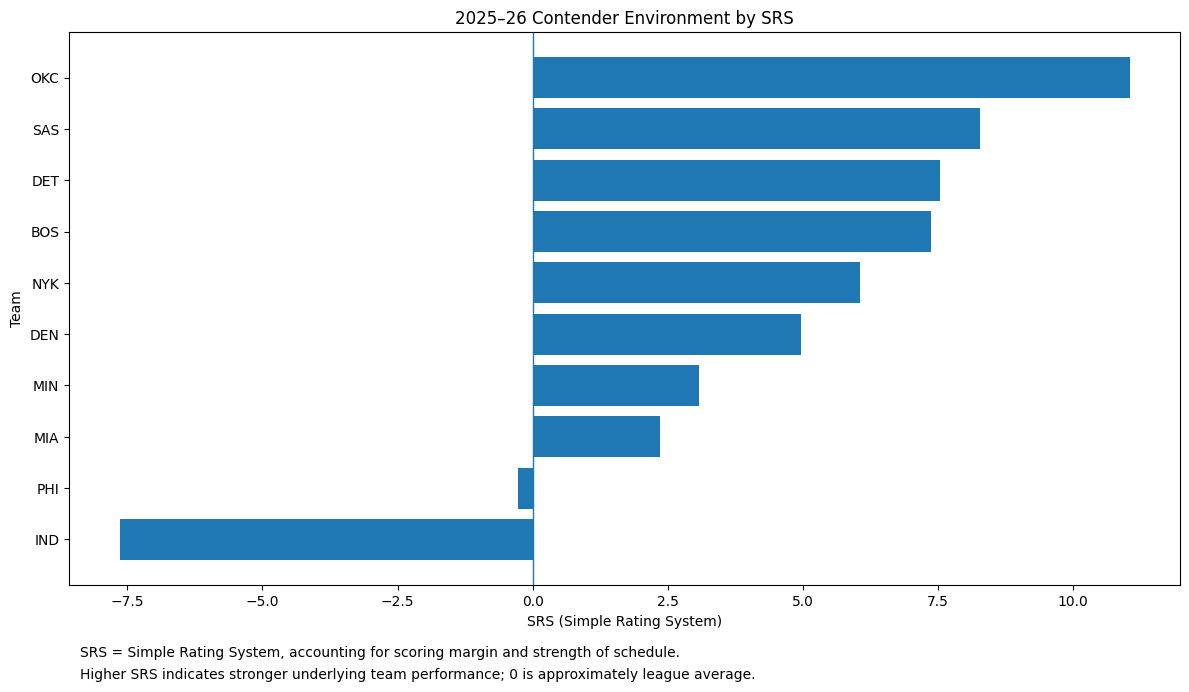

In [ ]:
plot_data = contender_baseline.sort_values(
    "SRS",
    ascending=True
).copy()

plt.figure(figsize=(12, 7))

plt.barh(
    plot_data["Team_Abbr"],
    plot_data["SRS"]
)

plt.axvline(
    0,
    linewidth=1
)

plt.xlabel("SRS (Simple Rating System)")
plt.ylabel("Team")
plt.title("2025–26 Contender Environment by SRS")

plt.text(
    0.01,
    -0.13,
    "SRS = Simple Rating System, accounting for scoring margin and strength of schedule.",
    transform=plt.gca().transAxes,
    fontsize=10
)

plt.text(
    0.01,
    -0.17,
    "Higher SRS indicates stronger underlying team performance; 0 is approximately league average.",
    transform=plt.gca().transAxes,
    fontsize=10
)

plt.tight_layout()
plt.show()

**Visualizing Minnesota's three scenarios against the environment**

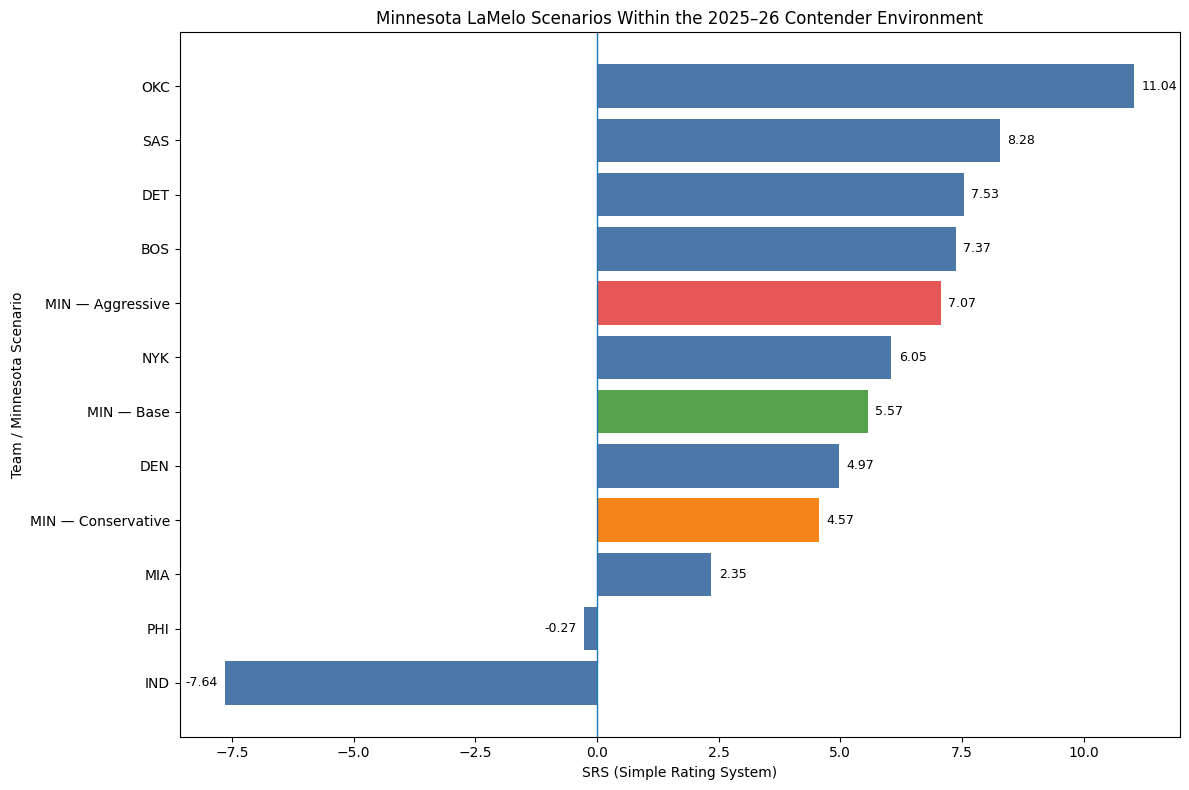

In [ ]:
scenario_values = {
    "MIN — Aggressive": min_srs_scenarios.loc[
        min_srs_scenarios["Scenario"] == "LaMelo Aggressive",
        "Projected_SRS"
    ].iloc[0],

    "MIN — Base": min_srs_scenarios.loc[
        min_srs_scenarios["Scenario"] == "LaMelo Base",
        "Projected_SRS"
    ].iloc[0],

    "MIN — Conservative": min_srs_scenarios.loc[
        min_srs_scenarios["Scenario"] == "LaMelo Conservative",
        "Projected_SRS"
    ].iloc[0]
}

ranked_data = []

for _, row in contender_baseline.iterrows():

    if row["Team_Abbr"] != "MIN":
        ranked_data.append({
            "Team": row["Team_Abbr"],
            "SRS": row["SRS"],
            "Type": "Actual"
        })

for label, value in scenario_values.items():
    ranked_data.append({
        "Team": label,
        "SRS": value,
        "Type": "Minnesota scenario"
    })

ranked_data = pd.DataFrame(ranked_data)

ranked_data = ranked_data.sort_values(
    "SRS",
    ascending=True
).reset_index(drop=True)

plt.figure(figsize=(12, 8))

colors = [
    "#4C78A8" if row["Type"] == "Actual"
    else "#F58518" if "Conservative" in row["Team"]
    else "#54A24B" if "Base" in row["Team"]
    else "#E45756"
    for _, row in ranked_data.iterrows()
]

plt.barh(
    ranked_data["Team"],
    ranked_data["SRS"],
    color=colors
)

plt.axvline(
    0,
    linewidth=1
)

for i, value in enumerate(ranked_data["SRS"]):
    offset = 0.15 if value >= 0 else -0.15

    plt.text(
        value + offset,
        i,
        f"{value:.2f}",
        va="center",
        ha="left" if value >= 0 else "right",
        fontsize=9
    )

plt.xlabel("SRS (Simple Rating System)")
plt.ylabel("Team / Minnesota Scenario")
plt.title("Minnesota LaMelo Scenarios Within the 2025–26 Contender Environment")

plt.tight_layout()
plt.show()

**Translating SRS into expected regular-season wins**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Use all 30 teams from Basketball-Reference
wins_model_data = srs_table[
    [
        team_col,
        wins_col,
        losses_col,
        srs_col
    ]
].copy()

wins_model_data.columns = [
    "Team",
    "W",
    "L",
    "SRS"
]

wins_model_data["Team"] = (
    wins_model_data["Team"]
    .astype(str)
    .str.replace("*", "", regex=False)
    .str.strip()
)

wins_model_data["W"] = pd.to_numeric(
    wins_model_data["W"],
    errors="coerce"
)

wins_model_data["L"] = pd.to_numeric(
    wins_model_data["L"],
    errors="coerce"
)

wins_model_data["SRS"] = pd.to_numeric(
    wins_model_data["SRS"],
    errors="coerce"
)

wins_model_data = wins_model_data.dropna(
    subset=["W", "L", "SRS"]
).copy()

wins_model_data["WinPct"] = (
    wins_model_data["W"]
    / (wins_model_data["W"] + wins_model_data["L"])
)

# Simple linear calibration
wins_slope, wins_intercept = np.polyfit(
    wins_model_data["SRS"],
    wins_model_data["WinPct"],
    1
)

wins_model_data["Fitted_WinPct"] = (
    wins_intercept
    + wins_slope * wins_model_data["SRS"]
)

wins_model_data["Fitted_Wins"] = (
    wins_model_data["Fitted_WinPct"] * 82
)

# Keep probabilities inside a realistic range
wins_model_data["Fitted_WinPct"] = (
    wins_model_data["Fitted_WinPct"]
    .clip(0.0, 1.0)
)

wins_model_data["Fitted_Wins"] = (
    wins_model_data["Fitted_WinPct"] * 82
)

print("SRS → WIN CALIBRATION")
print("=" * 100)

print(
    f"WinPct = {wins_intercept:.4f} + "
    f"{wins_slope:.4f} × SRS"
)

print(
    f"Correlation: "
    f"{wins_model_data['SRS'].corr(wins_model_data['WinPct']):.3f}"
)

print("\nCALIBRATION DATA")

print(
    wins_model_data[
        [
            "Team",
            "W",
            "L",
            "SRS",
            "WinPct",
            "Fitted_Wins"
        ]
    ]
    .sort_values("SRS", ascending=False)
    .round(3)
    .to_string(index=False)
)

SRS → WIN CALIBRATION
WinPct = 0.5000 + 0.0273 × SRS
Correlation: 0.972

CALIBRATION DATA
                  Team    W    L    SRS  WinPct  Fitted_Wins
 Oklahoma City Thunder 64.0 18.0  11.04   0.780       65.751
     San Antonio Spurs 62.0 20.0   8.28   0.756       59.563
       Detroit Pistons 60.0 22.0   7.53   0.732       57.882
        Boston Celtics 56.0 26.0   7.37   0.683       57.523
       New York Knicks 53.0 29.0   6.05   0.646       54.564
        Denver Nuggets 54.0 28.0   4.97   0.659       52.143
       Houston Rockets 52.0 30.0   4.87   0.634       51.918
     Charlotte Hornets 44.0 38.0   4.48   0.537       51.044
   Cleveland Cavaliers 52.0 30.0   3.78   0.634       49.475
Minnesota Timberwolves 49.0 33.0   3.07   0.598       47.883
       Toronto Raptors 46.0 36.0   2.75   0.561       47.165
         Atlanta Hawks 46.0 36.0   2.38   0.561       46.336
            Miami Heat 43.0 39.0   2.35   0.524       46.269
          Phoenix Suns 45.0 37.0   1.75   0.549       44

**Projecting Minnesota regular-season wins**

In [ ]:
min_srs_values = {
    "Actual 2025-26": min_srs,
    "LaMelo Conservative": min_srs + 1.5,
    "LaMelo Base": min_srs + 2.5,
    "LaMelo Aggressive": min_srs + 4.0
}

win_projection_rows = []

for scenario, scenario_srs in min_srs_values.items():

    projected_win_pct = (
        wins_intercept
        + wins_slope * scenario_srs
    )

    projected_win_pct = np.clip(
        projected_win_pct,
        0.0,
        1.0
    )

    projected_wins = (
        projected_win_pct * 82
    )

    win_projection_rows.append({
        "Scenario": scenario,
        "SRS": scenario_srs,
        "Projected_WinPct": projected_win_pct,
        "Projected_Wins": projected_wins,
        "Projected_Losses": 82 - projected_wins
    })

min_win_projection = pd.DataFrame(
    win_projection_rows
)

min_win_projection.round(2)

,Scenario,SRS,Projected_WinPct,Projected_Wins,Projected_Losses
0,Actual 2025-26,3.07,0.58,47.88,34.12
1,LaMelo Conservative,4.57,0.62,51.25,30.75
2,LaMelo Base,5.57,0.65,53.49,28.51
3,LaMelo Aggressive,7.07,0.69,56.85,25.15


**Calibrating SRS to actual game win probability**

In [ ]:
game_data = teams_2026.copy()

game_data["game_id"] = (
    game_data["game_id"].astype(str)
)

game_data = game_data[
    (game_data["season"] == 2026) &
    (game_data["season_type"] == 2) &
    (~game_data["game_id"].isin(special_games_2026))
].copy()

# Identify the home/away labels
print("HOME/AWAY VALUES:")
print(
    game_data["team_home_away"]
    .dropna()
    .astype(str)
    .unique()
)

print("\nTEAM WINNER VALUES:")
print(
    game_data["team_winner"]
    .dropna()
    .astype(str)
    .unique()
)

HOME/AWAY VALUES:
['away' 'home']

TEAM WINNER VALUES:
['False' 'True']


**Calibrating SRS difference to actual game win probability**

GAME-LEVEL DATASET
Games: 778
Home wins: 418
Home win rate: 0.537

SRS GAME CALIBRATION
Games with SRS data: 778
SRS difference range: -20.74 to 20.74

GAME WIN PROBABILITY MODEL
P(Home Win) = sigmoid(0.1801 + 0.1217 × SRS Difference)
Training accuracy: 0.689

When teams have equal SRS, modelled home win probability: 0.545


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


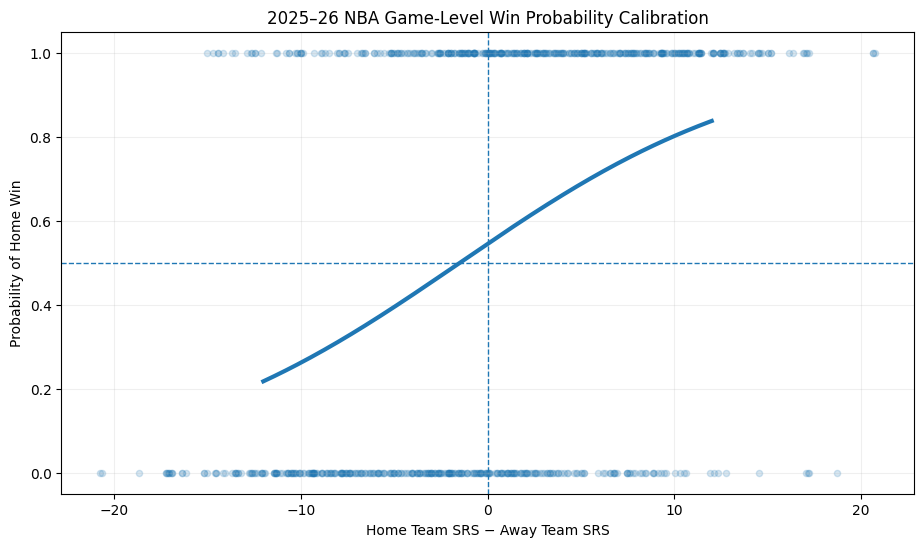

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# --------------------------------------------------
# Build 2025-26 regular-season game dataset
# --------------------------------------------------

game_data = teams_2026.copy()

game_data["game_id"] = game_data["game_id"].astype(str)

game_data = game_data[
    (game_data["season"] == 2026) &
    (game_data["season_type"] == 2) &
    (~game_data["game_id"].isin(special_games_2026))
].copy()

game_data["team_winner"] = (
    game_data["team_winner"]
    .astype(str)
    .str.lower()
    .eq("true")
)

# --------------------------------------------------
# Create home-team rows
# --------------------------------------------------

home_games = game_data[
    game_data["team_home_away"].astype(str).str.lower() == "home"
][
    [
        "game_id",
        "team_abbreviation",
        "team_score",
        "team_winner"
    ]
].copy()

home_games.columns = [
    "game_id",
    "home_team",
    "home_score",
    "home_winner"
]

# --------------------------------------------------
# Create away-team rows
# --------------------------------------------------

away_games = game_data[
    game_data["team_home_away"].astype(str).str.lower() == "away"
][
    [
        "game_id",
        "team_abbreviation",
        "team_score"
    ]
].copy()

away_games.columns = [
    "game_id",
    "away_team",
    "away_score"
]

# --------------------------------------------------
# Combine into one row per game
# --------------------------------------------------

games = home_games.merge(
    away_games,
    on="game_id",
    how="inner"
)

games = games.drop_duplicates("game_id").copy()

games["Home_Win"] = (
    games["home_winner"]
    .astype(int)
)

print("GAME-LEVEL DATASET")
print("=" * 80)

print(f"Games: {len(games):,}")
print(f"Home wins: {games['Home_Win'].sum():,}")
print(f"Home win rate: {games['Home_Win'].mean():.3f}")

# --------------------------------------------------
# Map ESPN abbreviations to Basketball-Reference teams
# --------------------------------------------------

team_name_map = {
    "ATL": "Atlanta Hawks",
    "BOS": "Boston Celtics",
    "BKN": "Brooklyn Nets",
    "CHA": "Charlotte Hornets",
    "CHI": "Chicago Bulls",
    "CLE": "Cleveland Cavaliers",
    "DAL": "Dallas Mavericks",
    "DEN": "Denver Nuggets",
    "DET": "Detroit Pistons",
    "GS": "Golden State Warriors",
    "GSW": "Golden State Warriors",
    "HOU": "Houston Rockets",
    "IND": "Indiana Pacers",
    "LAC": "Los Angeles Clippers",
    "LAL": "Los Angeles Lakers",
    "MEM": "Memphis Grizzlies",
    "MIA": "Miami Heat",
    "MIL": "Milwaukee Bucks",
    "MIN": "Minnesota Timberwolves",
    "NO": "New Orleans Pelicans",
    "NOP": "New Orleans Pelicans",
    "NY": "New York Knicks",
    "NYK": "New York Knicks",
    "OKC": "Oklahoma City Thunder",
    "ORL": "Orlando Magic",
    "PHI": "Philadelphia 76ers",
    "PHX": "Phoenix Suns",
    "POR": "Portland Trail Blazers",
    "SAC": "Sacramento Kings",
    "SAS": "San Antonio Spurs",
    "SA": "San Antonio Spurs",
    "TOR": "Toronto Raptors",
    "UTA": "Utah Jazz",
    "WAS": "Washington Wizards"
}

games["home_name"] = (
    games["home_team"]
    .map(team_name_map)
)

games["away_name"] = (
    games["away_team"]
    .map(team_name_map)
)

# --------------------------------------------------
# Create SRS lookup
# --------------------------------------------------

srs_lookup = (
    srs_table[
        [team_col, srs_col]
    ]
    .copy()
)

srs_lookup.columns = [
    "Team",
    "SRS"
]

srs_lookup["Team"] = (
    srs_lookup["Team"]
    .astype(str)
    .str.replace("*", "", regex=False)
    .str.strip()
)

srs_lookup["SRS"] = pd.to_numeric(
    srs_lookup["SRS"],
    errors="coerce"
)

srs_lookup = srs_lookup.dropna(
    subset=["Team", "SRS"]
)

srs_dict = dict(
    zip(
        srs_lookup["Team"],
        srs_lookup["SRS"]
    )
)

games["Home_SRS"] = games["home_name"].map(srs_dict)
games["Away_SRS"] = games["away_name"].map(srs_dict)

games = games.dropna(
    subset=["Home_SRS", "Away_SRS"]
).copy()

# --------------------------------------------------
# SRS difference
# --------------------------------------------------

games["SRS_Diff"] = (
    games["Home_SRS"]
    - games["Away_SRS"]
)

print("\nSRS GAME CALIBRATION")
print("=" * 80)

print(f"Games with SRS data: {len(games):,}")
print(
    f"SRS difference range: "
    f"{games['SRS_Diff'].min():.2f} to "
    f"{games['SRS_Diff'].max():.2f}"
)

# --------------------------------------------------
# Logistic regression
# --------------------------------------------------

X = games[["SRS_Diff"]]
y = games["Home_Win"]

game_model = LogisticRegression(
    C=100000,
    solver="lbfgs"
)

game_model.fit(X, y)

game_intercept = game_model.intercept_[0]
game_slope = game_model.coef_[0][0]

games["Model_Home_Win_Prob"] = (
    game_model.predict_proba(X)[:, 1]
)

print("\nGAME WIN PROBABILITY MODEL")
print("=" * 80)

print(
    f"P(Home Win) = sigmoid("
    f"{game_intercept:.4f} + "
    f"{game_slope:.4f} × SRS Difference)"
)

print(
    f"Training accuracy: "
    f"{game_model.score(X, y):.3f}"
)

# --------------------------------------------------
# Home-court effect implied by the model
# --------------------------------------------------

neutral_home_probability = (
    1 /
    (
        1 +
        np.exp(-game_intercept)
    )
)

print(
    f"\nWhen teams have equal SRS, "
    f"modelled home win probability: "
    f"{neutral_home_probability:.3f}"
)

# --------------------------------------------------
# Visualize probability curve
# --------------------------------------------------

srs_range = np.linspace(
    -12,
    12,
    200
)

probability_curve = game_model.predict_proba(
    srs_range.reshape(-1, 1)
)[:, 1]

plt.figure(figsize=(11, 6))

plt.scatter(
    games["SRS_Diff"],
    games["Home_Win"],
    alpha=0.18,
    s=20
)

plt.plot(
    srs_range,
    probability_curve,
    linewidth=3
)

plt.axhline(
    0.5,
    linestyle="--",
    linewidth=1
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Home Team SRS − Away Team SRS")
plt.ylabel("Probability of Home Win")
plt.title(
    "2025–26 NBA Game-Level Win Probability Calibration"
)

plt.ylim(-0.05, 1.05)
plt.grid(alpha=0.2)

plt.show()

**Minnesota matchup probabilities under the three LaMelo scenarios**

In [ ]:
# --------------------------------------------------
# Minnesota hypothetical SRS scenarios
# --------------------------------------------------

minnesota_scenarios = {
    "Actual 2025-26": min_srs,
    "LaMelo Conservative": min_srs + 1.5,
    "LaMelo Base": min_srs + 2.5,
    "LaMelo Aggressive": min_srs + 4.0
}

# --------------------------------------------------
# Opponents from the contender environment
# --------------------------------------------------

opponent_srs = {
    "Oklahoma City": 11.04,
    "San Antonio": 8.28,
    "Detroit": 7.53,
    "Boston": 7.37,
    "New York": 6.05,
    "Denver": 4.97,
    "Miami": 2.35,
    "Philadelphia": -0.27,
    "Indiana": -7.64
}

matchup_rows = []

for scenario, min_srs_value in minnesota_scenarios.items():

    for opponent, opp_srs in opponent_srs.items():

        # Minnesota at home
        home_diff = (
            min_srs_value
            - opp_srs
        )

        home_probability = game_model.predict_proba(
            np.array([[home_diff]])
        )[0, 1]

        # Minnesota on the road
        away_diff = (
            opp_srs
            - min_srs_value
        )

        away_probability = (
            1 -
            game_model.predict_proba(
                np.array([[away_diff]])
            )[0, 1]
        )

        matchup_rows.append({
            "Scenario": scenario,
            "Opponent": opponent,
            "Opponent_SRS": opp_srs,
            "MIN_SRS": min_srs_value,
            "MIN_Win_%_Home": home_probability,
            "MIN_Win_%_Away": away_probability
        })

matchup_probabilities = pd.DataFrame(
    matchup_rows
)

print("MINNESOTA MATCHUP PROBABILITIES")
print("=" * 110)

display(
    matchup_probabilities
    .pivot(
        index="Opponent",
        columns="Scenario",
        values="MIN_Win_%_Home"
    )
    .round(3)
)

MINNESOTA MATCHUP PROBABILITIES


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist

Scenario,Actual 2025-26,LaMelo Aggressive,LaMelo Base,LaMelo Conservative
Opponent,,,,
Boston,0.415,0.536,0.490,0.460
Denver,0.487,0.607,0.563,0.533
Detroit,0.410,0.531,0.485,0.455
Indiana,0.815,0.878,0.857,0.841
Miami,0.567,0.680,0.639,0.611
New York,0.455,0.575,0.530,0.500
Oklahoma City,0.312,0.425,0.381,0.353
Philadelphia,0.643,0.745,0.709,0.683
San Antonio,0.388,0.508,0.463,0.433


**Establish the team-adjustment framework**

In [ ]:
import pandas as pd
import numpy as np

# --------------------------------------------------
# 2025-26 baseline SRS
# --------------------------------------------------

team_adjustment = contender_baseline[
    [
        "Team",
        "SRS",
        "W",
        "L"
    ]
].copy()

team_adjustment.columns = [
    "Team",
    "Baseline_SRS",
    "Baseline_W",
    "Baseline_L"
]

# --------------------------------------------------
# Hypothetical roster scenarios
# --------------------------------------------------

team_adjustment["Scenario"] = "No major modeled change"

team_adjustment.loc[
    team_adjustment["Team"] == "Minnesota Timberwolves",
    "Scenario"
] = "LaMelo Ball added"

team_adjustment.loc[
    team_adjustment["Team"] == "Indiana Pacers",
    "Scenario"
] = "Tyrese Haliburton returns"

team_adjustment.loc[
    team_adjustment["Team"] == "Miami Heat",
    "Scenario"
] = "Major roster change"

team_adjustment.loc[
    team_adjustment["Team"] == "Philadelphia 76ers",
    "Scenario"
] = "Major roster change"

team_adjustment.loc[
    team_adjustment["Team"] == "Boston Celtics",
    "Scenario"
] = "Major roster change"

team_adjustment.loc[
    team_adjustment["Team"] == "Denver Nuggets",
    "Scenario"
] = "Roster change"

team_adjustment.loc[
    team_adjustment["Team"] == "Detroit Pistons",
    "Scenario"
] = "Roster change"

team_adjustment.loc[
    team_adjustment["Team"] == "New York Knicks",
    "Scenario"
] = "Roster change"

team_adjustment.loc[
    team_adjustment["Team"] == "San Antonio Spurs",
    "Scenario"
] = "Roster change"

team_adjustment.loc[
    team_adjustment["Team"] == "Oklahoma City Thunder",
    "Scenario"
] = "Baseline"

print("TEAM STRENGTH ADJUSTMENT FRAMEWORK")
print("=" * 100)

display(
    team_adjustment[
        [
            "Team",
            "Baseline_SRS",
            "Baseline_W",
            "Baseline_L",
            "Scenario"
        ]
    ].sort_values(
        "Baseline_SRS",
        ascending=False
    )
)

TEAM STRENGTH ADJUSTMENT FRAMEWORK


,Team,Baseline_SRS,Baseline_W,Baseline_L,Scenario
0,Oklahoma City Thunder,11.04,64.0,18.0,Baseline
1,San Antonio Spurs,8.28,62.0,20.0,Roster change
2,Detroit Pistons,7.53,60.0,22.0,Roster change
3,Boston Celtics,7.37,56.0,26.0,Major roster change
4,New York Knicks,6.05,53.0,29.0,Roster change
5,Denver Nuggets,4.97,54.0,28.0,Roster change
6,Minnesota Timberwolves,3.07,49.0,33.0,LaMelo Ball added
7,Miami Heat,2.35,43.0,39.0,Major roster change
8,Philadelphia 76ers,-0.27,45.0,37.0,Major roster change
9,Indiana Pacers,-7.64,19.0,63.0,Tyrese Haliburton returns


**Create the roster-impact assumptions**

In [ ]:
roster_impact = pd.DataFrame([
    {
        "Team": "Minnesota Timberwolves",
        "Change": "LaMelo Ball added",
        "Low_SRS_Impact": 1.5,
        "Base_SRS_Impact": 2.5,
        "High_SRS_Impact": 4.0
    },
    {
        "Team": "Indiana Pacers",
        "Change": "Tyrese Haliburton returns",
        "Low_SRS_Impact": 2.0,
        "Base_SRS_Impact": 3.5,
        "High_SRS_Impact": 5.0
    },
    {
        "Team": "Miami Heat",
        "Change": "Major roster change",
        "Low_SRS_Impact": -1.0,
        "Base_SRS_Impact": 1.0,
        "High_SRS_Impact": 3.0
    },
    {
        "Team": "Philadelphia 76ers",
        "Change": "Major roster change",
        "Low_SRS_Impact": 1.0,
        "Base_SRS_Impact": 2.5,
        "High_SRS_Impact": 4.0
    },
    {
        "Team": "Boston Celtics",
        "Change": "Major roster change",
        "Low_SRS_Impact": -2.0,
        "Base_SRS_Impact": -0.5,
        "High_SRS_Impact": 1.0
    },
    {
        "Team": "Denver Nuggets",
        "Change": "Roster change",
        "Low_SRS_Impact": -1.0,
        "Base_SRS_Impact": 0.0,
        "High_SRS_Impact": 1.0
    },
    {
        "Team": "Detroit Pistons",
        "Change": "Roster change",
        "Low_SRS_Impact": -1.0,
        "Base_SRS_Impact": 0.0,
        "High_SRS_Impact": 1.0
    },
    {
        "Team": "New York Knicks",
        "Change": "Roster change",
        "Low_SRS_Impact": -1.0,
        "Base_SRS_Impact": 0.0,
        "High_SRS_Impact": 1.0
    },
    {
        "Team": "San Antonio Spurs",
        "Change": "Roster change",
        "Low_SRS_Impact": -1.0,
        "Base_SRS_Impact": 0.0,
        "High_SRS_Impact": 1.0
    },
    {
        "Team": "Oklahoma City Thunder",
        "Change": "Baseline",
        "Low_SRS_Impact": 0.0,
        "Base_SRS_Impact": 0.0,
        "High_SRS_Impact": 0.0
    }
])

print("ROSTER IMPACT ASSUMPTIONS")
print("=" * 100)

display(
    roster_impact.round(2)
)

ROSTER IMPACT ASSUMPTIONS


,Team,Change,Low_SRS_Impact,Base_SRS_Impact,High_SRS_Impact
0,Minnesota Timberwolves,LaMelo Ball added,1.5,2.5,4.0
1,Indiana Pacers,Tyrese Haliburton returns,2.0,3.5,5.0
2,Miami Heat,Major roster change,-1.0,1.0,3.0
3,Philadelphia 76ers,Major roster change,1.0,2.5,4.0
4,Boston Celtics,Major roster change,-2.0,-0.5,1.0
5,Denver Nuggets,Roster change,-1.0,0.0,1.0
6,Detroit Pistons,Roster change,-1.0,0.0,1.0
7,New York Knicks,Roster change,-1.0,0.0,1.0
8,San Antonio Spurs,Roster change,-1.0,0.0,1.0
9,Oklahoma City Thunder,Baseline,0.0,0.0,0.0


**Measuring Indiana with and without Haliburton**

In [ ]:
import pandas as pd
import numpy as np

# --------------------------------------------------
# Load 2024-25 data
# --------------------------------------------------

player_2025_url = (
    "https://github.com/sportsdataverse/"
    "sportsdataverse-data/releases/download/"
    "espn_nba_player_boxscores/player_box_2025.parquet"
)

team_2025_url = (
    "https://github.com/sportsdataverse/"
    "sportsdataverse-data/releases/download/"
    "espn_nba_team_boxscores/team_box_2025.parquet"
)

players_2025 = pd.read_parquet(
    player_2025_url
)

teams_2025 = pd.read_parquet(
    team_2025_url
)

players_2025["game_id"] = (
    players_2025["game_id"].astype(str)
)

teams_2025["game_id"] = (
    teams_2025["game_id"].astype(str)
)

# --------------------------------------------------
# Regular season
# --------------------------------------------------

ind_players = players_2025[
    (players_2025["season"] == 2025) &
    (players_2025["season_type"] == 2) &
    (players_2025["team_abbreviation"] == "IND")
].copy()

ind_team = teams_2025[
    (teams_2025["season"] == 2025) &
    (teams_2025["season_type"] == 2) &
    (teams_2025["team_abbreviation"] == "IND")
].copy()

# --------------------------------------------------
# Haliburton game participation
# --------------------------------------------------

haliburton_games = (
    ind_players[
        ind_players["athlete_display_name"]
        .eq("Tyrese Haliburton")
    ]
    .groupby("game_id")["minutes"]
    .sum()
)

ind_team["Haliburton_Played"] = (
    ind_team["game_id"]
    .isin(
        haliburton_games[
            haliburton_games > 0
        ].index
    )
)

# --------------------------------------------------
# Possessions
# --------------------------------------------------

ind_team["Possessions"] = (
    ind_team["field_goals_attempted"]
    + 0.44 * ind_team["free_throws_attempted"]
    - ind_team["offensive_rebounds"]
    + ind_team["turnovers"]
)

ind_team["ORTG"] = (
    ind_team["team_score"]
    / ind_team["Possessions"]
    * 100
)

ind_team["DRTG"] = (
    ind_team["opponent_team_score"]
    / ind_team["Possessions"]
    * 100
)

ind_team["NET"] = (
    ind_team["ORTG"]
    - ind_team["DRTG"]
)

# --------------------------------------------------
# Compare Haliburton played vs missed
# --------------------------------------------------

haliburton_split = (
    ind_team
    .groupby("Haliburton_Played")
    .agg(
        Games=("game_id", "nunique"),
        PPG=("team_score", "mean"),
        Opp_PPG=("opponent_team_score", "mean"),
        ORTG=("ORTG", "mean"),
        DRTG=("DRTG", "mean"),
        NET=("NET", "mean"),
        Possessions=("Possessions", "mean")
    )
    .reset_index()
)

haliburton_split["Status"] = (
    haliburton_split["Haliburton_Played"]
    .map({
        True: "Haliburton played",
        False: "Haliburton missed"
    })
)

print("INDIANA 2024-25: HALIBURTON SPLIT")
print("=" * 100)

display(
    haliburton_split[
        [
            "Status",
            "Games",
            "PPG",
            "Opp_PPG",
            "ORTG",
            "DRTG",
            "NET",
            "Possessions"
        ]
    ].round(2)
)

# --------------------------------------------------
# Difference
# --------------------------------------------------

played = (
    haliburton_split[
        haliburton_split["Haliburton_Played"]
    ].iloc[0]
)

missed = (
    haliburton_split[
        ~haliburton_split["Haliburton_Played"]
    ].iloc[0]
)

haliburton_difference = pd.Series({
    "PPG_Difference":
        played["PPG"] - missed["PPG"],

    "Opp_PPG_Difference":
        played["Opp_PPG"] - missed["Opp_PPG"],

    "ORTG_Difference":
        played["ORTG"] - missed["ORTG"],

    "DRTG_Difference":
        played["DRTG"] - missed["DRTG"],

    "NET_Difference":
        played["NET"] - missed["NET"]
})

print("\nHALIBURTON IMPACT DIFFERENCE")
print("=" * 100)

display(
    haliburton_difference.round(2)
)

INDIANA 2024-25: HALIBURTON SPLIT


,Status,Games,PPG,Opp_PPG,ORTG,DRTG,NET,Possessions
0,Haliburton missed,9,118.78,122.11,110.07,113.39,-3.31,108.32
1,Haliburton played,73,117.19,114.27,116.08,113.05,3.03,101.07



HALIBURTON IMPACT DIFFERENCE


,0
PPG_Difference,-1.59
Opp_PPG_Difference,-7.84
ORTG_Difference,6.00
DRTG_Difference,-0.34
NET_Difference,6.34


**Convert the Haliburton evidence into an Indiana scenario range**

In [ ]:
haliburton_net_difference = (
    haliburton_difference["NET_Difference"]
)

indiana_baseline_srs = (
    contender_baseline.loc[
        contender_baseline["Team"]
        == "Indiana Pacers",
        "SRS"
    ].iloc[0]
)

indiana_scenarios = pd.DataFrame([
    {
        "Scenario": "Indiana Conservative",
        "Baseline_SRS": indiana_baseline_srs,
        "Impact_Share": 0.50
    },
    {
        "Scenario": "Indiana Base",
        "Baseline_SRS": indiana_baseline_srs,
        "Impact_Share": 0.75
    },
    {
        "Scenario": "Indiana Aggressive",
        "Baseline_SRS": indiana_baseline_srs,
        "Impact_Share": 1.00
    }
])

indiana_scenarios["SRS_Impact"] = (
    haliburton_net_difference
    * indiana_scenarios["Impact_Share"]
)

indiana_scenarios["Adjusted_SRS"] = (
    indiana_scenarios["Baseline_SRS"]
    + indiana_scenarios["SRS_Impact"]
)

print("INDIANA — HALIBURTON RETURN SCENARIOS")
print("=" * 100)

print(
    f"Observed 2024-25 NET difference: "
    f"{haliburton_net_difference:.2f}"
)

display(
    indiana_scenarios.round(2)
)

INDIANA — HALIBURTON RETURN SCENARIOS
Observed 2024-25 NET difference: 6.34


,Scenario,Baseline_SRS,Impact_Share,SRS_Impact,Adjusted_SRS
0,Indiana Conservative,-7.64,0.50,3.17,-4.47
1,Indiana Base,-7.64,0.75,4.76,-2.88
2,Indiana Aggressive,-7.64,1.00,6.34,-1.30


**Build the roster-change production table**

In [ ]:
import pandas as pd
import numpy as np

# --------------------------------------------------
# League-wide player production
# --------------------------------------------------

player_summary = (
    players_rs
    .groupby("athlete_display_name")
    .agg(
        GP=("game_id", "nunique"),
        MPG=("minutes", "mean"),
        PPG=("points", "mean"),
        APG=("assists", "mean"),
        FGA=("field_goals_attempted", "mean"),
        ThreePA=(
            "three_point_field_goals_attempted",
            "mean"
        ),
        FTA=("free_throws_attempted", "mean"),
        TOV=("turnovers", "mean")
    )
    .reset_index()
    .set_index("athlete_display_name")
)

# --------------------------------------------------
# Hypothetical roster movements
# --------------------------------------------------

roster_moves = {
    "Miami Heat": {
        "incoming": [
            "Giannis Antetokounmpo",
            "Bobby Portis",
            "Klay Thompson",
            "Tim Hardaway Jr.",
            "Nick Richards"
        ],
        "outgoing": [
            "Tyler Herro",
            "Norman Powell",
            "Jaime Jaquez Jr.",
            "Kel'el Ware"
        ]
    },

    "Philadelphia 76ers": {
        "incoming": [
            "Jaylen Brown",
            "LeBron James",
            "Anfernee Simons",
            "Kentavious Caldwell-Pope",
            "Dean Wade"
        ],
        "outgoing": [
            "Paul George",
            "Kelly Oubre Jr.",
            "Quentin Grimes",
            "Andre Drummond"
        ]
    },

    "Boston Celtics": {
        "incoming": [
            "Paul George",
            "Mike Conley",
            "Mitchell Robinson"
        ],
        "outgoing": [
            "Jaylen Brown",
            "Nikola Vucevic"
        ]
    },

    "Detroit Pistons": {
        "incoming": [
            "John Collins",
            "Gary Harris",
            "Isaiah Joe",
            "Taurean Prince"
        ],
        "outgoing": [
            "Tobias Harris",
            "Caris LeVert",
            "Isaiah Stewart",
            "Marcus Sasser"
        ]
    },

    "Denver Nuggets": {
        "incoming": [
            "DeMar DeRozan",
            "Marvin Bagley III"
        ],
        "outgoing": [
            "Tim Hardaway Jr.",
            "Peyton Watson"
        ]
    },

    "Indiana Pacers": {
        "incoming": [
            "Tyrese Haliburton"
        ],
        "outgoing": []
    }
}

# --------------------------------------------------
# Production aggregation
# --------------------------------------------------

production_rows = []

for team, moves in roster_moves.items():

    incoming_players = [
        p for p in moves["incoming"]
        if p in player_summary.index
    ]

    outgoing_players = [
        p for p in moves["outgoing"]
        if p in player_summary.index
    ]

    incoming = player_summary.loc[
        incoming_players
    ]

    outgoing = player_summary.loc[
        outgoing_players
    ]

    def total(df, column):
        if df.empty:
            return 0.0
        return df[column].sum()

    production_rows.append({
        "Team": team,

        "Incoming_PPG":
            total(incoming, "PPG"),

        "Outgoing_PPG":
            total(outgoing, "PPG"),

        "Net_PPG":
            total(incoming, "PPG")
            - total(outgoing, "PPG"),

        "Incoming_APG":
            total(incoming, "APG"),

        "Outgoing_APG":
            total(outgoing, "APG"),

        "Net_APG":
            total(incoming, "APG")
            - total(outgoing, "APG"),

        "Incoming_FGA":
            total(incoming, "FGA"),

        "Outgoing_FGA":
            total(outgoing, "FGA"),

        "Net_FGA":
            total(incoming, "FGA")
            - total(outgoing, "FGA"),

        "Incoming_3PA":
            total(incoming, "ThreePA"),

        "Outgoing_3PA":
            total(outgoing, "ThreePA"),

        "Net_3PA":
            total(incoming, "ThreePA")
            - total(outgoing, "ThreePA"),

        "Incoming_TOV":
            total(incoming, "TOV"),

        "Outgoing_TOV":
            total(outgoing, "TOV"),

        "Net_TOV":
            total(incoming, "TOV")
            - total(outgoing, "TOV")
    })

roster_production = pd.DataFrame(
    production_rows
)

print("ROSTER PRODUCTION CHANGES")
print("=" * 110)

display(
    roster_production[
        [
            "Team",
            "Incoming_PPG",
            "Outgoing_PPG",
            "Net_PPG",
            "Incoming_APG",
            "Outgoing_APG",
            "Net_APG",
            "Incoming_3PA",
            "Outgoing_3PA",
            "Net_3PA",
            "Incoming_TOV",
            "Outgoing_TOV",
            "Net_TOV"
        ]
    ]
    .round(2)
)

ROSTER PRODUCTION CHANGES


,Team,Incoming_PPG,Outgoing_PPG,Net_PPG,Incoming_APG,Outgoing_APG,Net_APG,Incoming_3PA,Outgoing_3PA,Net_3PA,Incoming_TOV,Outgoing_TOV,Net_TOV
0,Miami Heat,72.22,68.38,3.83,10.09,11.98,-1.90,20.56,19.18,1.38,6.86,6.65,0.21
1,Philadelphia 76ers,77.39,51.23,26.16,18.87,9.72,9.15,23.25,18.17,5.08,9.24,5.85,3.38
2,Boston Celtics,27.53,43.15,-15.62,7.37,8.35,-0.98,9.97,9.79,0.17,3.04,4.90,-1.86
3,Detroit Pistons,36.47,35.85,0.61,5.17,8.25,-3.08,16.00,11.40,4.61,3.60,4.34,-0.74
4,Denver Nuggets,28.88,28.10,0.78,5.52,3.41,2.12,2.78,10.52,-7.75,2.26,2.26,0.00
5,Indiana Pacers,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


**Measuring the size and direction of each roster change**

In [ ]:
# --------------------------------------------------
# Roster change profile
# --------------------------------------------------

roster_profile = roster_production.copy()

# Normalize each component relative to the observed
# magnitude across the selected teams.

def safe_zscore(series):
    std = series.std()

    if std == 0:
        return pd.Series(
            0.0,
            index=series.index
        )

    return (
        (series - series.mean())
        / std
    )

roster_profile["Scoring_Signal"] = safe_zscore(
    roster_profile["Net_PPG"]
)

roster_profile["Creation_Signal"] = safe_zscore(
    roster_profile["Net_APG"]
)

roster_profile["ThreePA_Signal"] = safe_zscore(
    roster_profile["Net_3PA"]
)

# Lower turnovers are better.
roster_profile["Turnover_Signal"] = safe_zscore(
    -roster_profile["Net_TOV"]
)

# --------------------------------------------------
# Composite offensive-change signal
# --------------------------------------------------

roster_profile["Offensive_Signal"] = (
    0.40 * roster_profile["Scoring_Signal"]
    +
    0.30 * roster_profile["Creation_Signal"]
    +
    0.15 * roster_profile["ThreePA_Signal"]
    +
    0.15 * roster_profile["Turnover_Signal"]
)

print("ROSTER CHANGE PROFILE")
print("=" * 100)

display(
    roster_profile[
        [
            "Team",
            "Net_PPG",
            "Net_APG",
            "Net_3PA",
            "Net_TOV",
            "Scoring_Signal",
            "Creation_Signal",
            "ThreePA_Signal",
            "Turnover_Signal",
            "Offensive_Signal"
        ]
    ]
    .sort_values(
        "Offensive_Signal",
        ascending=False
    )
    .round(2)
)

ROSTER CHANGE PROFILE


,Team,Net_PPG,Net_APG,Net_3PA,Net_TOV,Scoring_Signal,Creation_Signal,ThreePA_Signal,Turnover_Signal,Offensive_Signal
1,Philadelphia 76ers,26.16,9.15,5.08,3.38,1.75,1.87,0.97,-1.84,1.13
3,Detroit Pistons,0.61,-3.08,4.61,-0.74,-0.15,-0.90,0.87,0.52,-0.12
0,Miami Heat,3.83,-1.90,1.38,0.21,0.09,-0.63,0.17,-0.02,-0.13
5,Indiana Pacers,0.00,0.00,0.00,0.00,-0.20,-0.20,-0.13,0.09,-0.14
4,Denver Nuggets,0.78,2.12,-7.75,0.00,-0.14,0.28,-1.80,0.09,-0.23
2,Boston Celtics,-15.62,-0.98,0.17,-1.86,-1.36,-0.42,-0.09,1.16,-0.51


**Convert roster movement into SRS scenarios**

In [ ]:
# --------------------------------------------------
# Baseline SRS
# --------------------------------------------------

roster_profile["Baseline_SRS"] = (
    roster_profile["Team"]
    .map(
        contender_baseline.set_index("Team")["SRS"]
    )
)

# --------------------------------------------------
# Convert offensive signal to bounded SRS effect
# --------------------------------------------------

# This is a scenario translation, not a direct
# player-stat-to-SRS equation.

base_scale = 1.75

roster_profile["Base_SRS_Impact"] = (
    roster_profile["Offensive_Signal"]
    * base_scale
)

# Keep the modeled change inside a reasonable
# historical team-strength movement range.

roster_profile["Base_SRS_Impact"] = (
    roster_profile["Base_SRS_Impact"]
    .clip(-3.5, 3.5)
)

roster_profile["Low_SRS_Impact"] = (
    roster_profile["Base_SRS_Impact"]
    - 1.0
)

roster_profile["High_SRS_Impact"] = (
    roster_profile["Base_SRS_Impact"]
    + 1.0
)

roster_profile["Low_SRS"] = (
    roster_profile["Baseline_SRS"]
    + roster_profile["Low_SRS_Impact"]
)

roster_profile["Base_SRS"] = (
    roster_profile["Baseline_SRS"]
    + roster_profile["Base_SRS_Impact"]
)

roster_profile["High_SRS"] = (
    roster_profile["Baseline_SRS"]
    + roster_profile["High_SRS_Impact"]
)

print("ROSTER-ADJUSTED SRS SCENARIOS")
print("=" * 110)

display(
    roster_profile[
        [
            "Team",
            "Baseline_SRS",
            "Low_SRS_Impact",
            "Base_SRS_Impact",
            "High_SRS_Impact",
            "Low_SRS",
            "Base_SRS",
            "High_SRS"
        ]
    ]
    .sort_values(
        "Base_SRS",
        ascending=False
    )
    .round(2)
)

ROSTER-ADJUSTED SRS SCENARIOS


,Team,Baseline_SRS,Low_SRS_Impact,Base_SRS_Impact,High_SRS_Impact,Low_SRS,Base_SRS,High_SRS
3,Detroit Pistons,7.53,-1.21,-0.21,0.79,6.32,7.32,8.32
2,Boston Celtics,7.37,-1.89,-0.89,0.11,5.48,6.48,7.48
4,Denver Nuggets,4.97,-1.40,-0.40,0.60,3.57,4.57,5.57
0,Miami Heat,2.35,-1.23,-0.23,0.77,1.12,2.12,3.12
1,Philadelphia 76ers,-0.27,0.98,1.98,2.98,0.71,1.71,2.71
5,Indiana Pacers,-7.64,-1.25,-0.25,0.75,-8.89,-7.89,-6.89


**Build the final adjusted contender environment**

In [ ]:
# --------------------------------------------------
# Start with selected contender baseline
# --------------------------------------------------

final_environment = contender_baseline[
    [
        "Team",
        "SRS",
        "W",
        "L"
    ]
].copy()

final_environment = final_environment.rename(
    columns={
        "SRS": "Baseline_SRS"
    }
)

# --------------------------------------------------
# Add generic roster scenarios
# --------------------------------------------------

generic_scenarios = (
    roster_profile[
        [
            "Team",
            "Low_SRS",
            "Base_SRS",
            "High_SRS"
        ]
    ]
    .copy()
)

final_environment = final_environment.merge(
    generic_scenarios,
    on="Team",
    how="left"
)

# --------------------------------------------------
# Minnesota override
# --------------------------------------------------

final_environment.loc[
    final_environment["Team"]
    == "Minnesota Timberwolves",
    "Low_SRS"
] = 4.57

final_environment.loc[
    final_environment["Team"]
    == "Minnesota Timberwolves",
    "Base_SRS"
] = 5.57

final_environment.loc[
    final_environment["Team"]
    == "Minnesota Timberwolves",
    "High_SRS"
] = 7.07

# --------------------------------------------------
# Indiana override
# --------------------------------------------------

final_environment.loc[
    final_environment["Team"]
    == "Indiana Pacers",
    "Low_SRS"
] = -4.47

final_environment.loc[
    final_environment["Team"]
    == "Indiana Pacers",
    "Base_SRS"
] = -2.88

final_environment.loc[
    final_environment["Team"]
    == "Indiana Pacers",
    "High_SRS"
] = -1.30

# --------------------------------------------------
# Teams without modeled roster changes
# retain baseline SRS
# --------------------------------------------------

for column in [
    "Low_SRS",
    "Base_SRS",
    "High_SRS"
]:

    final_environment[column] = (
        final_environment[column]
        .fillna(
            final_environment["Baseline_SRS"]
        )
    )

print("FINAL ADJUSTED CONTENDER ENVIRONMENT")
print("=" * 110)

display(
    final_environment[
        [
            "Team",
            "Baseline_SRS",
            "Low_SRS",
            "Base_SRS",
            "High_SRS"
        ]
    ]
    .sort_values(
        "Base_SRS",
        ascending=False
    )
    .round(2)
)

FINAL ADJUSTED CONTENDER ENVIRONMENT


,Team,Baseline_SRS,Low_SRS,Base_SRS,High_SRS
0,Oklahoma City Thunder,11.04,11.04,11.04,11.04
1,San Antonio Spurs,8.28,8.28,8.28,8.28
2,Detroit Pistons,7.53,6.32,7.32,8.32
3,Boston Celtics,7.37,5.48,6.48,7.48
4,New York Knicks,6.05,6.05,6.05,6.05
6,Minnesota Timberwolves,3.07,4.57,5.57,7.07
5,Denver Nuggets,4.97,3.57,4.57,5.57
7,Miami Heat,2.35,1.12,2.12,3.12
8,Philadelphia 76ers,-0.27,0.71,1.71,2.71
9,Indiana Pacers,-7.64,-4.47,-2.88,-1.30


**Convert adjusted SRS into regular-season wins**

In [ ]:
# --------------------------------------------------
# SRS -> regular-season win projection
# --------------------------------------------------

win_projections = final_environment.copy()

for scenario in ["Low", "Base", "High"]:
    win_projections[f"{scenario}_WinPct"] = (
        0.500
        + 0.0273 * win_projections[f"{scenario}_SRS"]
    ).clip(0, 1)

    win_projections[f"{scenario}_Wins"] = (
        82 * win_projections[f"{scenario}_WinPct"]
    )

print("PROJECTED REGULAR-SEASON WINS")
print("=" * 100)

display(
    win_projections[
        [
            "Team",
            "Baseline_SRS",
            "Low_SRS",
            "Base_SRS",
            "High_SRS",
            "Low_Wins",
            "Base_Wins",
            "High_Wins"
        ]
    ]
    .sort_values(
        "Base_Wins",
        ascending=False
    )
    .round(2)
)

PROJECTED REGULAR-SEASON WINS


,Team,Baseline_SRS,Low_SRS,Base_SRS,High_SRS,Low_Wins,Base_Wins,High_Wins
0,Oklahoma City Thunder,11.04,11.04,11.04,11.04,65.71,65.71,65.71
1,San Antonio Spurs,8.28,8.28,8.28,8.28,59.54,59.54,59.54
2,Detroit Pistons,7.53,6.32,7.32,8.32,55.14,57.38,59.62
3,Boston Celtics,7.37,5.48,6.48,7.48,53.26,55.50,57.74
4,New York Knicks,6.05,6.05,6.05,6.05,54.54,54.54,54.54
6,Minnesota Timberwolves,3.07,4.57,5.57,7.07,51.23,53.47,56.83
5,Denver Nuggets,4.97,3.57,4.57,5.57,49.00,51.23,53.47
7,Miami Heat,2.35,1.12,2.12,3.12,43.51,45.75,47.99
8,Philadelphia 76ers,-0.27,0.71,1.71,2.71,42.59,44.83,47.07
9,Indiana Pacers,-7.64,-4.47,-2.88,-1.30,30.99,34.55,38.09


**Build the full 30-team regular-season environment**

In [ ]:
import pandas as pd
import numpy as np

bref_url = "https://www.basketball-reference.com/leagues/NBA_2026.html"
tables = pd.read_html(bref_url)

srs_table = tables[10].copy()

contender_baseline = pd.DataFrame({
    "Team": srs_table[("Unnamed: 1_level_0", "Team")],
    "SRS": pd.to_numeric(
        srs_table[("Unnamed: 9_level_0", "SRS")],
        errors="coerce"
    )
})

contender_baseline["Team"] = (
    contender_baseline["Team"]
    .astype(str)
    .str.replace(r"\*", "", regex=True)
    .str.strip()
)

contender_baseline = contender_baseline.dropna(subset=["SRS"])

full_league = pd.DataFrame({
    "Team": [
        "Atlanta Hawks",
        "Boston Celtics",
        "Brooklyn Nets",
        "Charlotte Hornets",
        "Chicago Bulls",
        "Cleveland Cavaliers",
        "Dallas Mavericks",
        "Denver Nuggets",
        "Detroit Pistons",
        "Golden State Warriors",
        "Houston Rockets",
        "Indiana Pacers",
        "LA Clippers",
        "Los Angeles Lakers",
        "Memphis Grizzlies",
        "Miami Heat",
        "Milwaukee Bucks",
        "Minnesota Timberwolves",
        "New Orleans Pelicans",
        "New York Knicks",
        "Oklahoma City Thunder",
        "Orlando Magic",
        "Philadelphia 76ers",
        "Phoenix Suns",
        "Portland Trail Blazers",
        "Sacramento Kings",
        "San Antonio Spurs",
        "Toronto Raptors",
        "Utah Jazz",
        "Washington Wizards"
    ]
})

full_league["Baseline_SRS"] = full_league["Team"].map(
    contender_baseline.set_index("Team")["SRS"]
)

# Basketball-Reference naming normalization
full_league.loc[
    full_league["Team"] == "LA Clippers",
    "Baseline_SRS"
] = 0.96

adjustments = {
    "Detroit Pistons": [6.32, 7.32, 8.32],
    "Boston Celtics": [5.48, 6.48, 7.48],
    "Denver Nuggets": [3.57, 4.57, 5.57],
    "Miami Heat": [1.12, 2.12, 3.12],
    "Philadelphia 76ers": [0.71, 1.71, 2.71],
    "Minnesota Timberwolves": [4.57, 5.57, 7.07],
    "Indiana Pacers": [-4.47, -2.88, -1.30]
}

full_league["Low_SRS"] = full_league["Baseline_SRS"]
full_league["Base_SRS"] = full_league["Baseline_SRS"]
full_league["High_SRS"] = full_league["Baseline_SRS"]

for team, values in adjustments.items():
    mask = full_league["Team"] == team
    full_league.loc[mask, "Low_SRS"] = values[0]
    full_league.loc[mask, "Base_SRS"] = values[1]
    full_league.loc[mask, "High_SRS"] = values[2]

print(
    "Teams found:",
    full_league["Baseline_SRS"].notna().sum(),
    "/ 30"
)

print(
    "Teams missing:",
    full_league["Baseline_SRS"].isna().sum()
)

display(
    full_league[
        [
            "Team",
            "Baseline_SRS",
            "Low_SRS",
            "Base_SRS",
            "High_SRS"
        ]
    ]
    .sort_values("Base_SRS", ascending=False)
    .round(2)
)

Teams found: 30 / 30
Teams missing: 0


,Team,Baseline_SRS,Low_SRS,Base_SRS,High_SRS
20,Oklahoma City Thunder,11.04,11.04,11.04,11.04
26,San Antonio Spurs,8.28,8.28,8.28,8.28
8,Detroit Pistons,7.53,6.32,7.32,8.32
1,Boston Celtics,7.37,5.48,6.48,7.48
19,New York Knicks,6.05,6.05,6.05,6.05
17,Minnesota Timberwolves,3.07,4.57,5.57,7.07
10,Houston Rockets,4.87,4.87,4.87,4.87
7,Denver Nuggets,4.97,3.57,4.57,5.57
3,Charlotte Hornets,4.48,4.48,4.48,4.48
5,Cleveland Cavaliers,3.78,3.78,3.78,3.78


**Simulate the regular season and determine playoff seeding**

In [ ]:
import pandas as pd
import numpy as np

team_url = (
    "https://github.com/sportsdataverse/"
    "sportsdataverse-data/releases/download/"
    "espn_nba_team_boxscores/team_box_2026.parquet"
)

teams = pd.read_parquet(team_url)

special_games = [
    "401838140",
    "401838141",
    "401838143",
    "401809839"
]

teams["game_id"] = teams["game_id"].astype(str)

teams_rs = teams[
    (teams["season"] == 2026) &
    (teams["season_type"] == 2) &
    (~teams["game_id"].isin(special_games))
].copy()

home = teams_rs[
    teams_rs["team_home_away"].astype(str).str.lower() == "home"
][
    [
        "game_id",
        "game_date",
        "team_name",
        "team_abbreviation"
    ]
].rename(
    columns={
        "team_name": "Home",
        "team_abbreviation": "Home_ABBR"
    }
)

away = teams_rs[
    teams_rs["team_home_away"].astype(str).str.lower() == "away"
][
    [
        "game_id",
        "team_name",
        "team_abbreviation"
    ]
].rename(
    columns={
        "team_name": "Away",
        "team_abbreviation": "Away_ABBR"
    }
)

games = (
    home
    .merge(away, on="game_id", how="inner")
    .drop_duplicates("game_id")
    .sort_values("game_date")
    .reset_index(drop=True)
)

if len(games) > 1230:
    games = games.iloc[:1230].copy()

# ESPN short-name -> full-name mapping

team_name_map = {
    "Hawks": "Atlanta Hawks",
    "Celtics": "Boston Celtics",
    "Nets": "Brooklyn Nets",
    "Hornets": "Charlotte Hornets",
    "Bulls": "Chicago Bulls",
    "Cavaliers": "Cleveland Cavaliers",
    "Mavericks": "Dallas Mavericks",
    "Nuggets": "Denver Nuggets",
    "Pistons": "Detroit Pistons",
    "Warriors": "Golden State Warriors",
    "Rockets": "Houston Rockets",
    "Pacers": "Indiana Pacers",
    "Clippers": "LA Clippers",
    "Lakers": "Los Angeles Lakers",
    "Grizzlies": "Memphis Grizzlies",
    "Heat": "Miami Heat",
    "Bucks": "Milwaukee Bucks",
    "Timberwolves": "Minnesota Timberwolves",
    "Pelicans": "New Orleans Pelicans",
    "Knicks": "New York Knicks",
    "Thunder": "Oklahoma City Thunder",
    "Magic": "Orlando Magic",
    "76ers": "Philadelphia 76ers",
    "Suns": "Phoenix Suns",
    "Trail Blazers": "Portland Trail Blazers",
    "Kings": "Sacramento Kings",
    "Spurs": "San Antonio Spurs",
    "Raptors": "Toronto Raptors",
    "Jazz": "Utah Jazz",
    "Wizards": "Washington Wizards"
}

games["Home_Full"] = games["Home"].map(team_name_map)
games["Away_Full"] = games["Away"].map(team_name_map)

east = {
    "Atlanta Hawks",
    "Boston Celtics",
    "Brooklyn Nets",
    "Charlotte Hornets",
    "Chicago Bulls",
    "Cleveland Cavaliers",
    "Detroit Pistons",
    "Indiana Pacers",
    "Miami Heat",
    "Milwaukee Bucks",
    "New York Knicks",
    "Orlando Magic",
    "Philadelphia 76ers",
    "Toronto Raptors",
    "Washington Wizards"
}

full_league["Conference"] = np.where(
    full_league["Team"].isin(east),
    "East",
    "West"
)

def simulate_regular_season(scenario, seed=42):

    rng = np.random.default_rng(seed)

    strength = full_league[
        ["Team", "Conference", scenario]
    ].rename(
        columns={scenario: "SRS"}
    )

    games_sim = games.merge(
        strength[["Team", "SRS"]],
        left_on="Home_Full",
        right_on="Team",
        how="left"
    ).rename(
        columns={"SRS": "Home_SRS"}
    ).drop(
        columns="Team"
    )

    games_sim = games_sim.merge(
        strength[["Team", "SRS"]],
        left_on="Away_Full",
        right_on="Team",
        how="left"
    ).rename(
        columns={"SRS": "Away_SRS"}
    ).drop(
        columns="Team"
    )

    intercept = 0.18012629092924107
    coefficient = 0.12166251306712295

    logit = (
        intercept +
        coefficient *
        (
            games_sim["Home_SRS"] -
            games_sim["Away_SRS"]
        )
    )

    games_sim["Home_Win_Prob"] = (
        1 /
        (
            1 +
            np.exp(-logit)
        )
    )

    games_sim["Home_Win"] = (
        rng.random(len(games_sim))
        <
        games_sim["Home_Win_Prob"]
    )

    games_sim["Winner"] = np.where(
        games_sim["Home_Win"],
        games_sim["Home_Full"],
        games_sim["Away_Full"]
    )

    win_counts = (
        games_sim["Winner"]
        .value_counts()
        .rename_axis("Team")
        .rename("Wins")
        .reset_index()
    )

    standings = full_league[
        ["Team", "Conference"]
    ].merge(
        win_counts,
        on="Team",
        how="left"
    )

    standings["Wins"] = (
        standings["Wins"]
        .fillna(0)
        .astype(int)
    )

    standings["Losses"] = (
        82 -
        standings["Wins"]
    )

    standings["Win_Pct"] = (
        standings["Wins"] /
        82
    )

    standings = (
        standings
        .sort_values(
            [
                "Conference",
                "Wins",
                "Team"
            ],
            ascending=[
                True,
                False,
                True
            ]
        )
        .reset_index(drop=True)
    )

    standings["Seed"] = (
        standings
        .groupby("Conference")
        .cumcount() +
        1
    )

    return games_sim, standings


low_games, low_standings = simulate_regular_season(
    "Low_SRS",
    seed=42
)

base_games, base_standings = simulate_regular_season(
    "Base_SRS",
    seed=42
)

high_games, high_standings = simulate_regular_season(
    "High_SRS",
    seed=42
)

print("Simulated games:", len(base_games))
print("Unique games:", base_games["game_id"].nunique())
print("Total wins:", base_standings["Wins"].sum())
print("Teams:", base_standings["Team"].nunique())

print()

for label, standings in [
    ("Conservative", low_standings),
    ("Base", base_standings),
    ("Aggressive", high_standings)
]:

    min_row = standings[
        standings["Team"] ==
        "Minnesota Timberwolves"
    ].iloc[0]

    print(
        f"{label}: "
        f"{min_row['Wins']}-{min_row['Losses']} | "
        f"Seed {int(min_row['Seed'])} | "
        f"{min_row['Conference']}"
    )

print()

display(
    base_standings[
        [
            "Team",
            "Conference",
            "Wins",
            "Losses",
            "Win_Pct",
            "Seed"
        ]
    ]
)

Simulated games: 1230
Unique games: 1230
Total wins: 1229
Teams: 30

Conservative: 55-27 | Seed 3 | West
Base: 56-26 | Seed 3 | West
Aggressive: 58-24 | Seed 2 | West



,Team,Conference,Wins,Losses,Win_Pct,Seed
0,Detroit Pistons,East,61,21,0.743902,1
1,Boston Celtics,East,56,26,0.682927,2
2,New York Knicks,East,56,26,0.682927,3
3,Toronto Raptors,East,52,30,0.634146,4
4,Miami Heat,East,48,34,0.585366,5
5,Philadelphia 76ers,East,48,34,0.585366,6
6,Atlanta Hawks,East,45,37,0.548780,7
7,Charlotte Hornets,East,44,38,0.536585,8
8,Cleveland Cavaliers,East,44,38,0.536585,9
9,Indiana Pacers,East,35,47,0.426829,10


In [ ]:
print("Games:", len(base_games))
print("Unique games:", base_games["game_id"].nunique())

print("\nTeams:")
print(base_standings["Team"].nunique())

print("\nWins:")
print(base_standings["Wins"].describe())

print("\nTotal wins:")
print(base_standings["Wins"].sum())

print("\nBase standings:")
display(
    base_standings[
        [
            "Team",
            "Conference",
            "Wins",
            "Losses",
            "Win_Pct",
            "Seed"
        ]
    ]
    .sort_values(
        ["Conference", "Wins"],
        ascending=[True, False]
    )
)

Games: 1230
Unique games: 1230

Teams:
30

Wins:
count    30.000000
mean     40.966667
std      12.144201
min      19.000000
25%      32.000000
50%      43.000000
75%      48.750000
max      61.000000
Name: Wins, dtype: float64

Total wins:
1229

Base standings:


,Team,Conference,Wins,Losses,Win_Pct,Seed
0,Detroit Pistons,East,61,21,0.743902,1
1,Boston Celtics,East,56,26,0.682927,2
2,New York Knicks,East,56,26,0.682927,3
3,Toronto Raptors,East,52,30,0.634146,4
4,Miami Heat,East,48,34,0.585366,5
5,Philadelphia 76ers,East,48,34,0.585366,6
6,Atlanta Hawks,East,45,37,0.548780,7
7,Charlotte Hornets,East,44,38,0.536585,8
8,Cleveland Cavaliers,East,44,38,0.536585,9
9,Indiana Pacers,East,35,47,0.426829,10


**Build the dynamic best-of-7 series simulator**




In [ ]:
import numpy as np

series_intercept = 0.18012629092924107
series_coefficient = 0.12166251306712295

def game_win_probability(
    home_srs,
    away_srs
):
    logit = (
        series_intercept +
        series_coefficient *
        (home_srs - away_srs)
    )

    return 1 / (1 + np.exp(-logit))


def simulate_series(
    team_a,
    team_b,
    srs_map,
    seed=None
):
    rng = np.random.default_rng(seed)

    wins = {
        team_a: 0,
        team_b: 0
    }

    # 2-2-1-1-1 format
    home_team = [
        team_a,
        team_a,
        team_b,
        team_b,
        team_a,
        team_b,
        team_a
    ]

    away_team = [
        team_b,
        team_b,
        team_a,
        team_a,
        team_b,
        team_a,
        team_b
    ]

    for home, away in zip(
        home_team,
        away_team
    ):

        if wins[team_a] == 4 or wins[team_b] == 4:
            break

        home_srs = srs_map[home]
        away_srs = srs_map[away]

        probability = game_win_probability(
            home_srs,
            away_srs
        )

        home_wins = (
            rng.random() < probability
        )

        winner = (
            home
            if home_wins
            else away
        )

        wins[winner] += 1

    return (
        team_a
        if wins[team_a] == 4
        else team_b
    )

**Validate the playoff series simulator**

In [ ]:
base_srs_map = dict(
    zip(
        full_league["Team"],
        full_league["Base_SRS"]
    )
)

validation_pairs = [
    (
        "Minnesota Timberwolves",
        "Denver Nuggets"
    ),
    (
        "Minnesota Timberwolves",
        "Oklahoma City Thunder"
    ),
    (
        "Minnesota Timberwolves",
        "New York Knicks"
    )
]

validation_results = []

for team_a, team_b in validation_pairs:

    wins = 0

    for i in range(5000):

        winner = simulate_series(
            team_a,
            team_b,
            base_srs_map,
            seed=i
        )

        if winner == team_a:
            wins += 1

    validation_results.append({
        "Series": f"{team_a} vs {team_b}",
        "Team A Series Win %": wins / 5000
    })

validation_results = pd.DataFrame(
    validation_results
)

display(
    validation_results.round(3)
)

,Series,Team A Series Win %
0,Minnesota Timberwolves vs Denver Nuggets,0.584
1,Minnesota Timberwolves vs Oklahoma City Thunder,0.192
2,Minnesota Timberwolves vs New York Knicks,0.482


**Simulate the full postseason from the modeled standings**

In [ ]:
def get_srs_map(scenario):
    return dict(
        zip(
            full_league["Team"],
            full_league[scenario]
        )
    )


def simulate_play_in(
    conference_standings,
    srs_map,
    rng
):
    seeded = (
        conference_standings
        .sort_values(
            "Wins",
            ascending=False
        )
        .reset_index(drop=True)
    )

    seeds = {
        i + 1: seeded.iloc[i]["Team"]
        for i in range(10)
    }

    # 7 vs 8
    winner_78 = simulate_series(
        seeds[7],
        seeds[8],
        srs_map,
        seed=int(rng.integers(1_000_000_000))
    )

    loser_78 = (
        seeds[8]
        if winner_78 == seeds[7]
        else seeds[7]
    )

    # 9 vs 10
    winner_910 = simulate_series(
        seeds[9],
        seeds[10],
        srs_map,
        seed=int(rng.integers(1_000_000_000))
    )

    # Loser of 9/10 eliminated
    # Winner plays loser of 7/8
    winner_final = simulate_series(
        loser_78,
        winner_910,
        srs_map,
        seed=int(rng.integers(1_000_000_000))
    )

    return {
        1: seeds[1],
        2: seeds[2],
        3: seeds[3],
        4: seeds[4],
        5: seeds[5],
        6: seeds[6],
        7: winner_78,
        8: winner_final
    }


def simulate_conference_playoffs(
    standings,
    srs_map,
    rng
):

    east = standings[
        standings["Conference"] == "East"
    ].sort_values(
        "Wins",
        ascending=False
    )

    west = standings[
        standings["Conference"] == "West"
    ].sort_values(
        "Wins",
        ascending=False
    )

    east_seeds = simulate_play_in(
        east,
        srs_map,
        rng
    )

    west_seeds = simulate_play_in(
        west,
        srs_map,
        rng
    )

    def round_simulation(
        matchups
    ):

        winners = []

        for team_a, team_b in matchups:

            winners.append(
                simulate_series(
                    team_a,
                    team_b,
                    srs_map,
                    seed=int(
                        rng.integers(
                            1_000_000_000
                        )
                    )
                )
            )

        return winners

    def conference_rounds(seeds):

        # First round
        r1 = round_simulation([
            (seeds[1], seeds[8]),
            (seeds[4], seeds[5]),
            (seeds[3], seeds[6]),
            (seeds[2], seeds[7])
        ])

        # Semifinals
        r2 = round_simulation([
            (r1[0], r1[1]),
            (r1[2], r1[3])
        ])

        # Conference final
        r3 = round_simulation([
            (r2[0], r2[1])
        ])

        return r3[0]

    east_champion = conference_rounds(
        east_seeds
    )

    west_champion = conference_rounds(
        west_seeds
    )

    return east_champion, west_champion

**Calculate Minnesota's playoff progression probabilities**

In [ ]:
def run_playoff_probability_simulation(
    scenario,
    n_simulations=5000,
    seed=12345
):

    rng = np.random.default_rng(seed)

    srs_map = get_srs_map(scenario)

    results = {
        "Playoffs": 0,
        "First_Round": 0,
        "Conference_Semifinals": 0,
        "Conference_Finals": 0,
        "NBA_Finals": 0,
        "Champion": 0
    }

    for _ in range(n_simulations):

        # Regular season
        _, standings = simulate_regular_season(
            scenario,
            seed=int(
                rng.integers(
                    1_000_000_000
                )
            )
        )

        min_row = standings[
            standings["Team"] ==
            "Minnesota Timberwolves"
        ].iloc[0]

        min_conf = min_row["Conference"]

        conf_standings = standings[
            standings["Conference"] ==
            min_conf
        ].sort_values(
            "Wins",
            ascending=False
        )

        min_seed = (
            conf_standings
            .reset_index(drop=True)
            .index[
                conf_standings["Team"] ==
                "Minnesota Timberwolves"
            ][0] + 1
        )

        # Seeds 1-6 automatically make playoffs.
        # Seeds 7-10 enter play-in.
        if min_seed <= 10:
            results["Playoffs"] += 1

        if min_seed > 10:
            continue

        # Simulate play-in if necessary
        if min_seed >= 7:

            playoff_seeds = simulate_play_in(
                conf_standings,
                srs_map,
                rng
            )

            if "Minnesota Timberwolves" not in \
               playoff_seeds.values():

                continue

        else:

            playoff_seeds = {
                i + 1: conf_standings.iloc[i]["Team"]
                for i in range(8)
            }

        # --------------------------------------------------
        # First round
        # --------------------------------------------------

        first_round_matchups = [
            (playoff_seeds[1], playoff_seeds[8]),
            (playoff_seeds[4], playoff_seeds[5]),
            (playoff_seeds[3], playoff_seeds[6]),
            (playoff_seeds[2], playoff_seeds[7])
        ]

        first_round_winners = []

        for a, b in first_round_matchups:

            winner = simulate_series(
                a,
                b,
                srs_map,
                seed=int(
                    rng.integers(
                        1_000_000_000
                    )
                )
            )

            first_round_winners.append(
                winner
            )

        if "Minnesota Timberwolves" not in \
           first_round_winners:

            continue

        results["First_Round"] += 1

        # --------------------------------------------------
        # Conference semifinals
        # --------------------------------------------------

        semifinals = [
            (
                first_round_winners[0],
                first_round_winners[1]
            ),
            (
                first_round_winners[2],
                first_round_winners[3]
            )
        ]

        semifinal_winners = []

        for a, b in semifinals:

            winner = simulate_series(
                a,
                b,
                srs_map,
                seed=int(
                    rng.integers(
                        1_000_000_000
                    )
                )
            )

            semifinal_winners.append(
                winner
            )

        if "Minnesota Timberwolves" not in \
           semifinal_winners:

            continue

        results["Conference_Semifinals"] += 1

        # --------------------------------------------------
        # Conference final
        # --------------------------------------------------

        conference_champion = simulate_series(
            semifinal_winners[0],
            semifinal_winners[1],
            srs_map,
            seed=int(
                rng.integers(
                    1_000_000_000
                )
            )
        )

        if conference_champion != \
           "Minnesota Timberwolves":

            continue

        results["Conference_Finals"] += 1

        # --------------------------------------------------
        # Other conference
        # --------------------------------------------------

        other_conf = (
            "West"
            if min_conf == "East"
            else "East"
        )

        other_standings = standings[
            standings["Conference"] ==
            other_conf
        ].sort_values(
            "Wins",
            ascending=False
        )

        other_seeds = simulate_play_in(
            other_standings,
            srs_map,
            rng
        )

        other_r1 = [
            (other_seeds[1], other_seeds[8]),
            (other_seeds[4], other_seeds[5]),
            (other_seeds[3], other_seeds[6]),
            (other_seeds[2], other_seeds[7])
        ]

        other_r1_winners = [
            simulate_series(
                a,
                b,
                srs_map,
                seed=int(
                    rng.integers(
                        1_000_000_000
                    )
                )
            )
            for a, b in other_r1
        ]

        other_r2_winners = [
            simulate_series(
                other_r1_winners[0],
                other_r1_winners[1],
                srs_map,
                seed=int(
                    rng.integers(
                        1_000_000_000
                    )
                )
            ),
            simulate_series(
                other_r1_winners[2],
                other_r1_winners[3],
                srs_map,
                seed=int(
                    rng.integers(
                        1_000_000_000
                    )
                )
            )
        ]

        other_champion = simulate_series(
            other_r2_winners[0],
            other_r2_winners[1],
            srs_map,
            seed=int(
                rng.integers(
                    1_000_000_000
                )
            )
        )

        # --------------------------------------------------
        # NBA Finals
        # --------------------------------------------------

        results["NBA_Finals"] += 1

        champion = simulate_series(
            "Minnesota Timberwolves",
            other_champion,
            srs_map,
            seed=int(
                rng.integers(
                    1_000_000_000
                )
            )
        )

        if champion == "Minnesota Timberwolves":
            results["Champion"] += 1

    return pd.Series(results) / n_simulations

**Run the three Minnesota scenarios**

In [ ]:
scenario_results = pd.DataFrame({
    "Conservative": run_playoff_probability_simulation(
        "Low_SRS",
        n_simulations=5000,
        seed=100
    ),

    "Base": run_playoff_probability_simulation(
        "Base_SRS",
        n_simulations=5000,
        seed=200
    ),

    "Aggressive": run_playoff_probability_simulation(
        "High_SRS",
        n_simulations=5000,
        seed=300
    )
})

scenario_results = (
    scenario_results
    .T
    .mul(100)
    .round(1)
)

display(scenario_results)

,Playoffs,First_Round,Conference_Semifinals,Conference_Finals,NBA_Finals,Champion
Conservative,100.0,58.1,17.5,4.5,4.5,2.1
Base,100.0,65.9,23.0,7.0,7.0,3.7
Aggressive,100.0,75.6,35.8,12.8,12.8,6.9


**Playoff progression across scenarios**

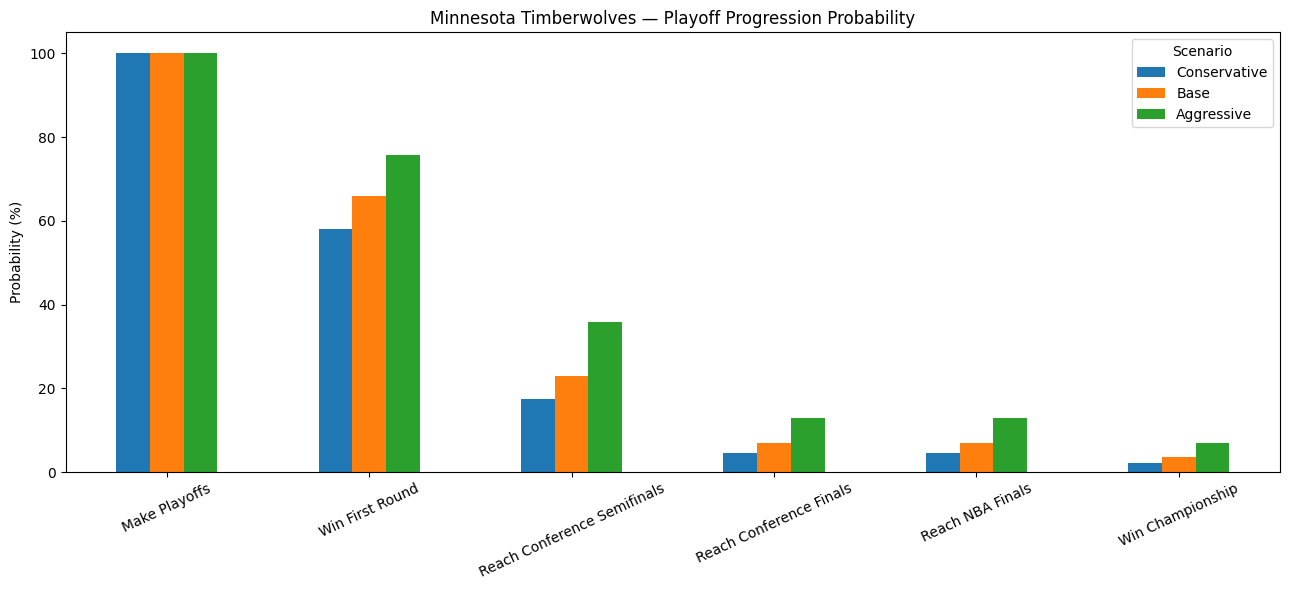

In [ ]:
import matplotlib.pyplot as plt

progression = scenario_results[
    [
        "Playoffs",
        "First_Round",
        "Conference_Semifinals",
        "Conference_Finals",
        "NBA_Finals",
        "Champion"
    ]
].copy()

progression.columns = [
    "Make Playoffs",
    "Win First Round",
    "Reach Conference Semifinals",
    "Reach Conference Finals",
    "Reach NBA Finals",
    "Win Championship"
]

ax = progression.T.plot(
    kind="bar",
    figsize=(13, 6)
)

ax.set_ylabel("Probability (%)")
ax.set_xlabel("")
ax.set_title(
    "Minnesota Timberwolves — Playoff Progression Probability"
)

ax.legend(
    title="Scenario"
)

plt.xticks(rotation=25)
plt.ylim(0, 105)
plt.tight_layout()
plt.show()

**Championship probability by scenario**

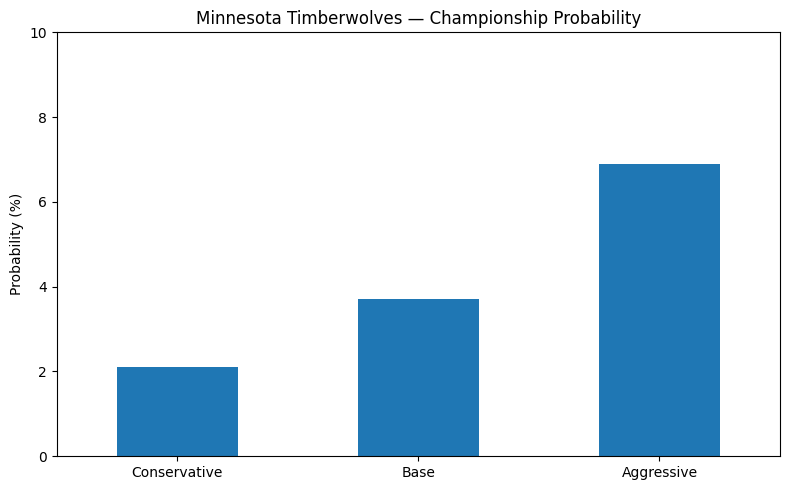

In [ ]:
championship = scenario_results[
    ["Champion"]
].copy()

championship = championship.rename(
    columns={
        "Champion": "Championship Probability"
    }
)

ax = championship.plot(
    kind="bar",
    figsize=(8, 5),
    legend=False
)

ax.set_ylabel("Probability (%)")
ax.set_xlabel("")
ax.set_title(
    "Minnesota Timberwolves — Championship Probability"
)

ax.set_xticklabels(
    championship.index,
    rotation=0
)

plt.ylim(0, 10)
plt.tight_layout()
plt.show()

**Minnesota's modeled strength vs expected wins**

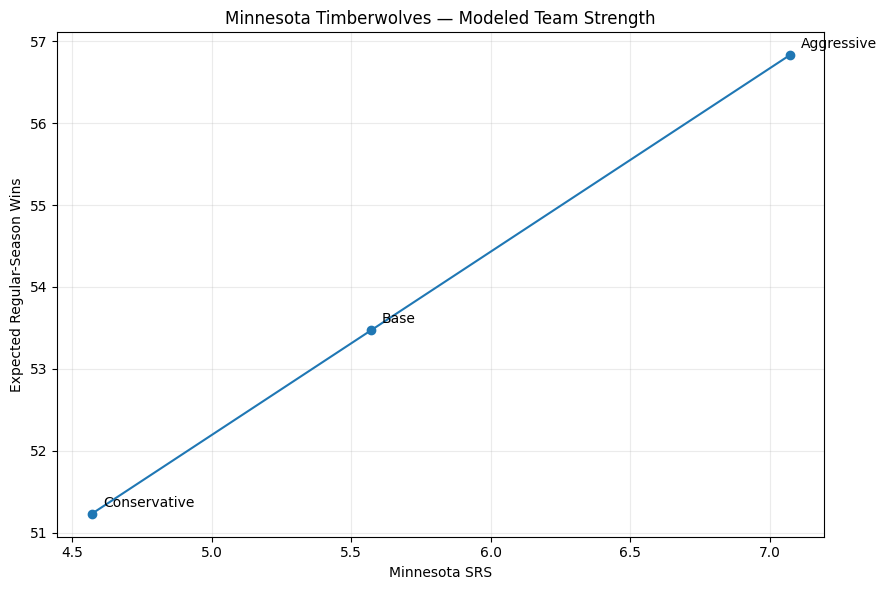

In [ ]:
scenario_strength = pd.DataFrame({
    "Scenario": [
        "Conservative",
        "Base",
        "Aggressive"
    ],
    "SRS": [
        4.57,
        5.57,
        7.07
    ],
    "Expected_Wins": [
        51.23,
        53.47,
        56.83
    ]
})

plt.figure(figsize=(9, 6))

plt.plot(
    scenario_strength["SRS"],
    scenario_strength["Expected_Wins"],
    marker="o"
)

for _, row in scenario_strength.iterrows():

    plt.annotate(
        row["Scenario"],
        (
            row["SRS"],
            row["Expected_Wins"]
        ),
        xytext=(8, 5),
        textcoords="offset points"
    )

plt.xlabel("Minnesota SRS")
plt.ylabel("Expected Regular-Season Wins")
plt.title(
    "Minnesota Timberwolves — Modeled Team Strength"
)

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

** Base-case playoff funnel**

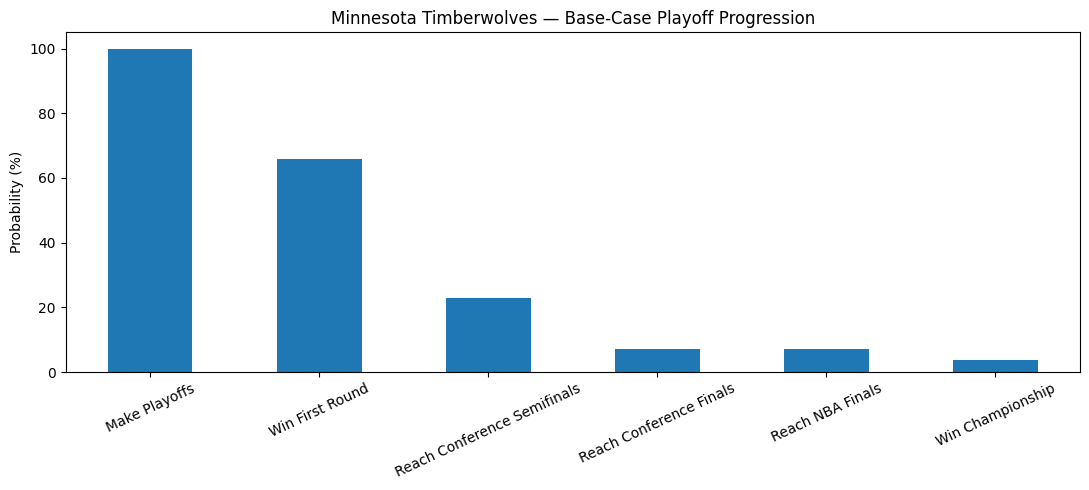

In [ ]:
base_funnel = pd.Series({
    "Make Playoffs": scenario_results.loc[
        "Base", "Playoffs"
    ],
    "Win First Round": scenario_results.loc[
        "Base", "First_Round"
    ],
    "Reach Conference Semifinals": scenario_results.loc[
        "Base", "Conference_Semifinals"
    ],
    "Reach Conference Finals": scenario_results.loc[
        "Base", "Conference_Finals"
    ],
    "Reach NBA Finals": scenario_results.loc[
        "Base", "NBA_Finals"
    ],
    "Win Championship": scenario_results.loc[
        "Base", "Champion"
    ]
})

ax = base_funnel.plot(
    kind="bar",
    figsize=(11, 5),
    legend=False
)

ax.set_ylabel("Probability (%)")
ax.set_xlabel("")
ax.set_title(
    "Minnesota Timberwolves — Base-Case Playoff Progression"
)

plt.xticks(rotation=25)
plt.ylim(0, 105)
plt.tight_layout()
plt.show()

**Compare Minnesota with the major contenders**

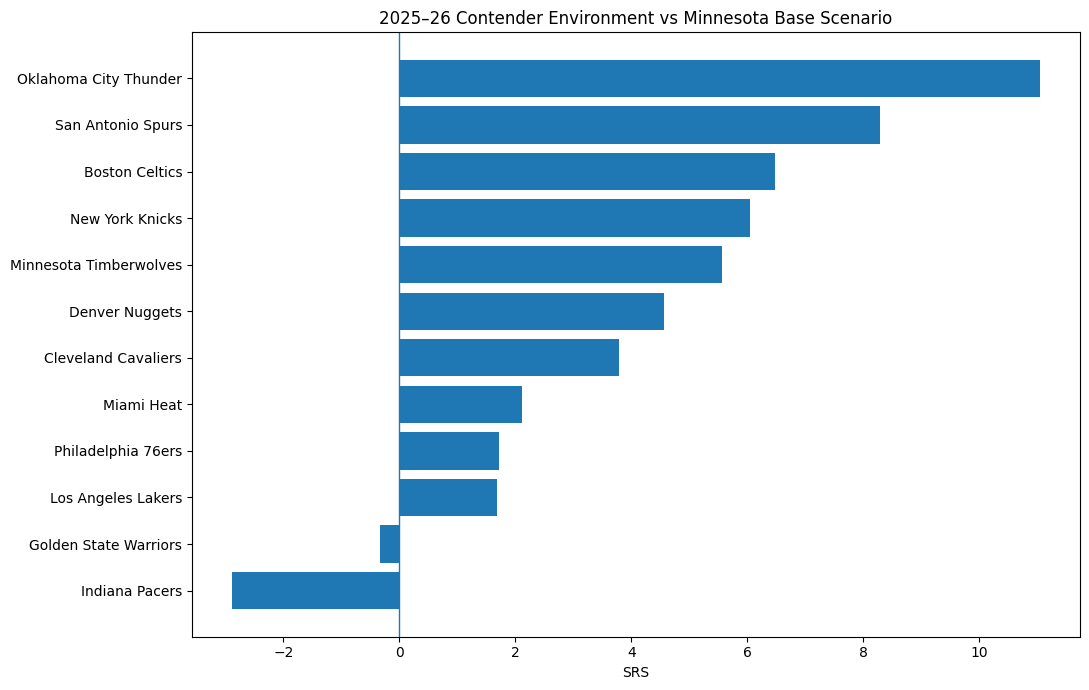

In [ ]:
# 4.40A — Compare Minnesota with major contenders

comparison_teams = {
    "Oklahoma City Thunder": 11.04,
    "San Antonio Spurs": 8.28,
    "Boston Celtics": 6.48,
    "New York Knicks": 6.05,
    "Minnesota Timberwolves": 5.57,
    "Denver Nuggets": 4.57,
    "Cleveland Cavaliers": 3.78,
    "Miami Heat": 2.12,
    "Los Angeles Lakers": 1.68,
    "Philadelphia 76ers": 1.71,
    "Golden State Warriors": -0.34,
    "Indiana Pacers": -2.88
}

srs_comparison = (
    pd.DataFrame(
        list(comparison_teams.items()),
        columns=["Team", "SRS"]
    )
    .sort_values("SRS", ascending=False)
)

plt.figure(figsize=(11, 7))

plt.barh(
    srs_comparison["Team"],
    srs_comparison["SRS"]
)

plt.axvline(
    0,
    linewidth=1
)

plt.xlabel("SRS")
plt.title(
    "2025–26 Contender Environment vs Minnesota Base Scenario"
)

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

**Expected wins comparison**

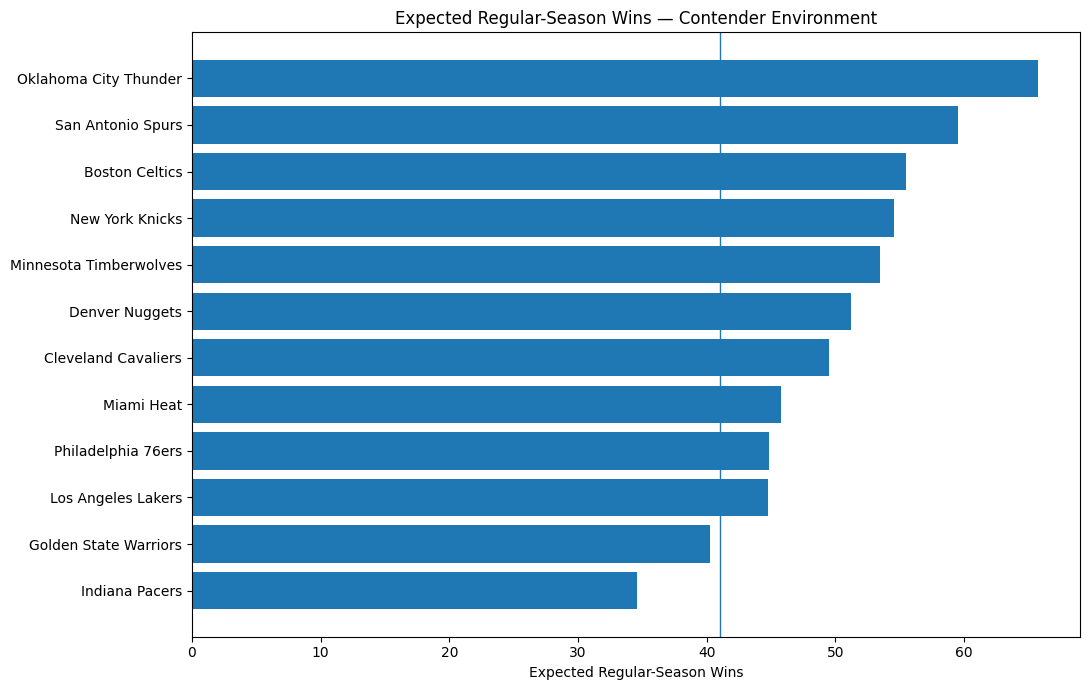

In [ ]:
# 4.40B — Expected wins comparison

wins_comparison = srs_comparison.copy()

wins_comparison["Expected_Wins"] = (
    82 *
    (
        0.5000 +
        0.0273 *
        wins_comparison["SRS"]
    )
)

plt.figure(figsize=(11, 7))

plt.barh(
    wins_comparison["Team"],
    wins_comparison["Expected_Wins"]
)

plt.axvline(
    41,
    linewidth=1
)

plt.xlabel("Expected Regular-Season Wins")
plt.title(
    "Expected Regular-Season Wins — Contender Environment"
)

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

**Minnesota's three scenarios against the contenders**

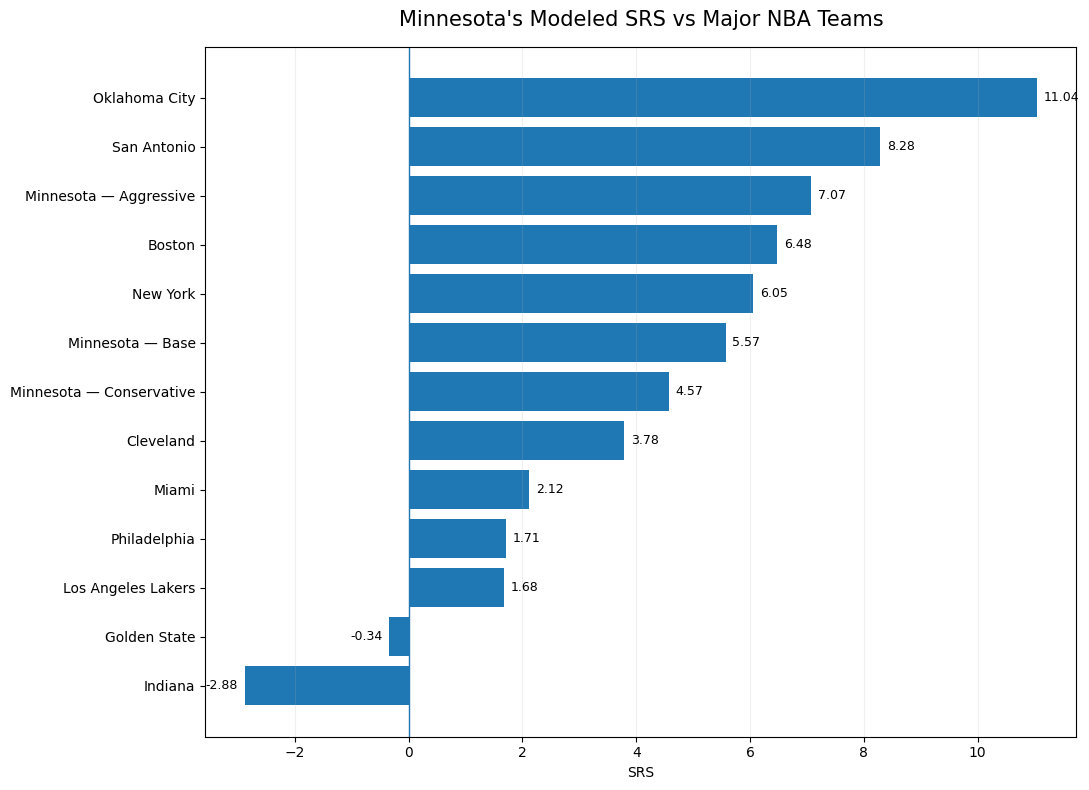

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

comparison = pd.DataFrame([
    ["Oklahoma City", 11.04, "Team"],
    ["San Antonio", 8.28, "Team"],
    ["Boston", 6.48, "Team"],
    ["New York", 6.05, "Team"],
    ["Minnesota — Aggressive", 7.07, "Minnesota"],
    ["Minnesota — Base", 5.57, "Minnesota"],
    ["Minnesota — Conservative", 4.57, "Minnesota"],
    ["Cleveland", 3.78, "Team"],
    ["Philadelphia", 1.71, "Team"],
    ["Miami", 2.12, "Team"],
    ["Los Angeles Lakers", 1.68, "Team"],
    ["Golden State", -0.34, "Team"],
    ["Indiana", -2.88, "Team"]
], columns=["Team", "SRS", "Type"])

comparison = comparison.sort_values("SRS", ascending=True)

plt.figure(figsize=(11, 8))

bars = plt.barh(
    comparison["Team"],
    comparison["SRS"]
)

plt.axvline(0, linewidth=1)

for bar, value in zip(bars, comparison["SRS"]):
    offset = 0.12 if value >= 0 else -0.12
    ha = "left" if value >= 0 else "right"

    plt.text(
        value + offset,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}",
        va="center",
        ha=ha,
        fontsize=9
    )

plt.title(
    "Minnesota's Modeled SRS vs Major NBA Teams",
    fontsize=15,
    pad=15
)

plt.xlabel("SRS")
plt.ylabel("")

plt.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()